<a href="https://colab.research.google.com/github/fatemehmsh90/Business-Data-Analytics-Project/blob/main/FINAL_IBS_PROJECT_FATEMEH.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Drug Substitute Identification and Risk Analysis in the Pharmaceutical Supply Chain Using Data-Driven Similarity and Exploratory Analytics**
**Programme:** MSc IT – Business Data Analytics

**Author:** Fatemeh Mashayekhiahangarani
  
**Repo:** Business-Data-Analytics-Project  

> This notebook contains the analysis, figures, and notes used for the dissertation.  
> Final report will be a separate PDF (uploaded to Moodle). Code and figures are saved here.

---


##**EXECUTIVE SUMMARY**

This project aims to introduce a data-driven system that can identify suitable alternative drugs in times of drug shortage. Drug shortages are a growing problem in many healthcare systems, and finding suitable alternatives is of great importance to patients, hospitals, and supply chain managers. The goal of this study was to build a simple, explainable and reproducible model that can help suggest substitute drugs by using the large MID dataset and modern text-embedding methods.

The work began with preparing and cleaning the dataset. The MID data includes medicine names, descriptions, therapeutic classes, and other structured fields. A combined text field was created for each medicine by merging different description parts. This helped capture more information in a single representation. Basic exploratory analysis showed that the dataset is large, diverse, and suitable for building a similarity-based model.

The methodology used two main feature types: text features and structured features. For the text part, a light Sentence-BERT model (MiniLM-L6-v2) was used to create embeddings. For the structured part, one-hot encoding was applied to fields such as chemical class and therapeutic class. These two sets of features were then merged into one combined vector for each medicine. A cosine-similarity matrix and clustering methods were used to explore relationships between medicines.

Model evaluation, including external validation with the Kaggle dataset, was also performed at the suggestion of the supervisor to increase the accuracy of the proposed model. However, the model could still find general similarity patterns. Metrics such as Hit@k and Precision@k showed low scores for exact substitutes, but the behaviour matched expectations given the differences between datasets.

A sensitivity analysis showed that text features are better for finding close substitutes, while structured features are better for grouping medicines into broader categories. This supported the decision to use a combined model. A substitution network graph was built to reveal strong similarity links, and two new indicators were introduced. The Substitutability Index (SI) measures how many alternatives each drug has, and the Shortage Risk Index (SRI) shows how vulnerable a drug is when substitutes are limited.

The results showed that some medicines, such as common antibiotics, have many alternatives, while others, such as eye drops and special-use injections, have almost no substitutes. These findings can help managers identify high-risk products and plan better during shortages. A simple Python-based dashboard concept was also created to show how these results can be used in practice.
Overall, the project demonstrates that combining text and structured data can support decision-making in pharmaceutical supply chains, especially for shortage management and risk assessment.

# **CHAPTER 1 – INTRODUCTION**

## **1.1	BACKGROUND OF THE STUDY**

Drug shortage is an important problem in the world. When a medicine is not available in the market, patients and doctors need to find a substitute drug. This process is often slow and manual, and people usually look only at the active ingredient. However, this is not enough because medicines can be different in their chemical structure, mechanism of action, and therapeutic class. If these differences are not considered, the chosen substitute may not work well and can cause treatment delays or higher costs (Aronson et al., 2023a; Aronson et al., 2023b).

There are many reasons for drug shortages, such as production problems, dependency on one manufacturer, and weak distribution systems. These problems hurt patients and put pressure on the healthcare system (Andy and Andy, 2023).
In recent years, data-driven approaches have been used more often to support decision-making. Using data science and combining it with artificial intelligence, these methods can find patterns faster and help select better substitutes.

For text information about drugs, embedding methods can also be used to understand meaning and measure similarity between medicines (Kauffman et al., 2025).

This study aims to build a data-driven approach for identifying substitute medicines. This study try to combine textual and structural features to calculate similarities and provide results that can help pharmaceutical supply company managers make better and faster decisions.



## **1.2	PROBLEM STATEMENT**

Today, there is no simple and data-based system that can automatically find substitute medicines. Pharmacists and doctors often decide only by reading the drug information or by using their own experience. This process takes time and sometimes gives wrong results, because it only looks at the active ingredient and ignores other important details like chemical structure, mechanism of action, and therapeutic class. When drug shortages become more common, quick and correct decisions are very important. However, many countries and companies still use basic or manual tools.

Machine learning and data analytics can help to find hidden patterns and possible drug substitutes that support better decision-making in the pharmaceutical supply chain. Still, there is no research that brings both textual and structured features together for this purpose.

***Therefore, the main problem of this study is:***

how to combine textual data (like product descriptions) and structured data (like therapeutic class, chemical structure, and mechanism of action) to predict possible substitute medicines, and how to use these results for better business and supply chain decisions.


## **1.3	RESEARCH AIM AND OBJECTIVES**
**Research Aim:**  
The main aim of this study is to build a data-driven method that can find substitute medicines in a more accurate way.
To do this, the study combines two types of information:

1.	Text information from drug descriptions, and
2.	Structured information such as therapeutic class, chemical structure, and mechanism of action.

By using both types of data together, the study tries to understand which medicines are similar and which ones can be used as substitutes during a drug shortage.
  

**Research Objectives:**  
- Create text embeddings for the drug descriptions to understand meaning and similarity (Kauffman et al., 2025).
- Encode the structured features of each drug (Therapeutic / Chemical / Action classes).
- Combine text and structured features to calculate similarity between medicines.
- Identify the Top-k substitute drugs for each medicine.
- Apply clustering and build a substitution network.
- Create two indicators: SI (Substitutability Index) and SRI (Shortage Risk Index) for business analysis.
- Validate the results using an external dataset (Iyer, 2025).

These objectives help the study create a method that is both technically strong and useful for real decision-making in the pharmaceutical supply chain.

## **1.4	RESEARCH QUESTIONS**
This study is guided by several research questions that help to give a clear direction to the project and show what the analysis aims to answer.

**RQ1:**

Does combining text data (such as drug descriptions) and structured data (such as therapeutic class, chemical structure, and mechanism of action) improve the accuracy of finding substitute medicines?

This question will be addressed by studies that show how different drug properties can influence decisions to substitute drugs for each other. (Aronson et al., 2023b).


**RQ2:**

Which therapeutic classes have the highest substitutability, and which ones have the lowest substitutability?

This is an important question between all questions in pharmaceutical supply chains that must be answered because some drug groups are more sensitive to shortages than others. (Andy and Andy, 2023).


**RQ3:**

Can the substitution index (SI) and the shortage risk index (SRI) help describe the risk level of different drug groups in a simple and useful way?

This can be supported by the idea of data-driven decisions in the supply chain. (Iyer, 2025).


**RQ4:**

How can the results of this model support real decisions in procurement and the pharmaceutical supply chain?

This question focuses on the practical value of the analysis.

## **1.5	SCOPE & SIGNIFICANCE**
**Scope:**

In this study, I use the MID dataset as the main data source. This dataset includes information such as drug name, text description, therapeutic class, chemical class, and mechanism of action. The analysis is limited to these fields. I do not use price data, sales data, or patient-level data.

The main focus is to see if these text and structured fields are enough to suggest possible substitute medicines. To make the results more reliable, I also plan to use an external dataset for checking the model, for example a public medicine substitute dataset from Kaggle or a similar source.

The project does not go deep into company finance or detailed cost modelling, but the results can still be useful for pharmacy managers and supply chain planners.


**Significance:**

Drug shortages are a real and growing problem in many countries. They can delay treatment and create stress for patients, doctors and pharmacists (Aronson et al., 2023a). In many places, the current tools for finding substitutes are slow, manual, or not updated. A data-driven method that can suggest substitutes faster and in a more structured way may help to reduce delays and improve access to medicines. By using text embeddings and structured features together, the model does not rely only on the active ingredient or the drug name, but also on therapeutic class, chemical properties and mechanism of action.

Overall, this study can be a small but useful step towards smarter tools for managing the pharmaceutical supply chain.

## **1.6 OVERVIEW OF ANALYTICAL APPROACH**

This study follows a clear and step-by-step analytical process. The goal is to combine text information and structured drug features to build a method that can suggest substitute medicines and help understand shortage risks.

**Step 1: Exploratory Data Analysis (EDA)**

The first step is to look at the data and understand its basic shape. In the first review, I examine the number of drugs, missing values, and distribution of treatment categories in the database. This helps me see if the data needs cleaning and what patterns appear at the start.

**Step 2: Text Embeddings**

The text descriptions of each drug are turned into numerical vectors using embedding methods. These vectors help the model understand the meaning of the text better (Kauffman et al., 2025).

**Step 3: Structured Features**

In this step, we will convert therapeutic classes, chemical classes, and mechanisms of action into numerical values. These features are of great importance because they show us how drugs can be related in terms of therapeutics and properties or chemical formulas.

**Step 4: Combining Text and Structure**

The text embeddings and structured features are merged to create a full representation of each drug.

**Step 5: Similarity Calculation**

For every drug, similarity to other drugs is calculated using cosine similarity. This helps identify possible substitute medicines.

**Step 6: Clustering and Substitution Network**

Drugs that are similar are grouped together. This network is then displayed as a graph to show how the drug ingredients are related and which groups have stronger substitution bonds with each other.

**Step 7: Model Evaluation**

The results are checked using an external dataset. Metrics such as Hit@k and Precision@k are used to see how well the method finds correct substitutes.

**Step 8: Business Insights**

Finally, two indicators are created:

**•	SI (Substitutability Index)**

**•	SRI (Shortage Risk Index)**

These two indicators help decision-makers in the pharmaceutical supply chain to better understand which drug groups have good alternatives and which groups face higher prices.

This approach makes the analysis technically strong and also useful for real decision-making in the pharmaceutical supply chain.

## **1.7 STRUCTURE OF THE DISSERTATION**

This dissertation is divided into several parts.
In first Chapter it gives us an introduction to the topic. It explains the problem, the aim of the study, the research questions, and the general analytical approach.

Chapter Two presents the literature review. This chapter describes drug shortages, substitution patterns, data analytics methods, similarity techniques, text embeddings, and how these tools can be used in the pharmaceutical supply chain.

Chapter Three explains the research methodology. It introduces the MID dataset and describes the steps for data cleaning, text embedding, encoding structured features, and calculating similarity.

Chapter Four shows the results of the exploratory data analysis (EDA).

Chapter Five presents the similarity model output, including substitute drug lists, clustering results, and the substitution network.

Chapter Six and Seven focuses on model evaluation and shows how well the method performs using metrics such as Hit@k and Precision@k.

Chapter Eight provides business insights. It explains the SI (Substitutability Index) and SRI (Shortage Risk Index) and shows how the results can support decisions in procurement and supply chain planning.

Finally, Chapter Nine includes the conclusion, limitations of the study, and suggestions for future work.



# **CHAPTER 2 – LITERATURE REVIEW**

## **2.1 DRUG SHORTAGES: DEFINITIONS, CAUSES, IMPACTS**

Drug shortages are a serious problem in many countries. According to Aronson et al. (2023a), A drug shortage happens when a medicine cannot meet the therapeutic needs of patients, either locally or nationally. Shortages can be short or long, and they can affect the quality of treatment and patient safety. There are many causes why drug shortages occur. Aronson et al. (2023b) explain that problems in manufacturing, lack of raw materials, quality control issues, dependence on a single supplier, strict import rules, and distribution problems are some of the main reasons.

Sometimes companies reduce production because the profit of a drug is low. In other cases, transportation delays or global crises create disruptions in the supply chain. A review article by Adak (2024) shows that drug shortages not only create technical problems but also serious human problems. Shortages can increase treatment costs, delay therapy, and create stress for patients, doctors, and pharmacists. Adak (2024) also notes that shortages reduce trust in the healthcare system and make daily work in pharmacies more difficult.

In many places, pharmacists decide based only on the active ingredient. This can be risky because two drugs with the same active ingredient can still have very different chemical structures, mechanisms of action, or therapeutic classes.

Because of these challenges, recent research suggests that healthcare systems should use more data-driven tools and smarter methods to support substitution decisions. These tools can help make faster and more accurate choices and reduce the negative impacts of shortages.

## **2.2 MEDICINE SUBSTITUTION: CONCEPTS & CHALLENGES**

Medicine substitution means using another medicine when the original one is not available. Also, substitution can happen for many reasons, such as a drug shortage, high price, production problems, or a change in the treatment plan.

There are two common types of substitution.

**1) Generic substitution**

In this case, the original medicine is replaced with a generic version that has the same active ingredient. This method is widely used, but it is not always enough. Even if two medicines have the same active ingredient, they may still have different chemical structures or mechanisms of action.

**2) Therapeutic substitution**

Here, the medicine is replaced with another medicine that has a different active ingredient but a similar therapeutic effect. This type of substitution is more complex and requires deeper pharmaceutical knowledge.

Studies show that finding the right substitute is not always easy. One major challenge is that information sources are often old or incomplete. In many countries, pharmacists must search manually through different websites or books to find similar medicines. This takes time and may lead to mistakes.
Another problem is that similarity between medicines is not only about the active ingredient.


A safe and correct substitution should consider:

- chemical structure

- mechanism of action

- therapeutic class

- side effects

- drug interactions

Because of these challenges, I recommend that using data-driven tools and machine learning methods to support substitution decisions.

These tools can combine text and structured data and suggest substitute medicines faster and more accurately.


## **2.3	DATA-DRIVEN APPROACHES IN HEALTHCARE & SUPPLY CHAIN**

In recent years, data-driven methods have become more common in healthcare and in the pharmaceutical supply chain. Data-driven decision making can reduce errors, improve planning, and make operations faster. Many countries now try to use data to predict drug shortages, manage purchasing, and find substitute medicines more effectively.

Data-driven approaches often include several basic steps:
collecting data, cleaning the data, exploring it with simple analysis, building machine learning models, and creating dashboards or reports for decision-makers. These steps help doctors, pharmacists, and managers make choices based on real information instead of guesswork.

Some real-works use the machine learning models to predict drug shortages or supply risks. Other clustering methods to group similar medicines together and find patterns in drug usage.
These techniques can help identify which drug groups are more sensitive to shortages.

Data-driven methods are especially important in the pharmaceutical supply chain because:


- drug shortages are increasing

- large amounts of data are available

- traditional systems are slow

- managers need smarter tools for planning

The many current systems for finding substitute medicines are old, slow, and often incomplete. This makes it difficult for pharmacists to make fast and accurate decisions.

More advanced techniques, such as text embeddings and similarity search, are now being used in healthcare. These methods help computers understand the meaning of drug descriptions and find medicines that are truly similar based on both text and structure.

Overall, research shows that data-driven tools can increase speed, reduce mistakes, and improve decision-making in healthcare and the drug supply chain.

## **2.4	TEXT EMBEDDINGS, SIMILARITY METHODS & ML FOR SUBSTITUTION**

In recent years, the use of artificial intelligence for analysing medical and drug-related text has grown very quickly. One important method in this area is text embedding. According to Kauffman et al. (2025), text embedding means turning written text into numbers so that a computer can understand the meaning in a simple way. When a text is converted into a numeric vector, it becomes possible to measure how similar two pieces of text are.

In drug information, the text often contains many useful details, such as how the medicine works, what it is used for, and safety warnings. If these descriptions are turned into embeddings, we can see which medicines have similar meanings or similar uses.

Another important part of this process is similarity search. After creating embeddings, we can compare medicines using methods like cosine similarity. This method shows how close two drugs are based on their numerical vectors. A higher similarity score usually means that the two medicines may work in a similar way or may be potential substitutes. Using similarity search is helpful for medicine substitution because it gives a more structured and objective way to find possible alternatives.

The manual decision-making is often slow and may not always be accurate, so data-driven tools can help improve the process. Other studies also use machine learning techniques such as clustering, ranking models, or classifiers. But for identifying substitute medicines, the combination of text embedding + similarity calculation is one of the simplest and most effective approaches. Text embeddings are combined with the structured features of each drug, such as therapeutic class and chemical class. This makes the similarity calculation more complete because it considers both the meaning of the text and the medical structure of the drug.

Overall, embedding and similarity methods provide a strong scientific base for building systems that can suggest substitute medicines in a fast, accurate, and safer way.


## **2.5	SUMMARY OF LITERATURE GAPS**

Previous studies have explored many important topics related to drug shortages, medicine substitution, and data analytics.

However, there are still several gaps that show why this study is needed and how it adds something new to the field.


**First gap:**

Many studies focus on only one part of the problem. For example, some papers mainly discuss the causes and impacts of drug shortages (Aronson et al., 2023a; Adak, 2024). Other studies look only at how pharmacies choose substitute medicines (Andy & Andy, 2023).

There are not many studies that look at both shortage and substitution together in a connected way.


**Second gap:**

Most current substitution tools are old and mostly manual. They often check only the active ingredient and do not consider other important elements such as chemical structure, mechanism of action, or therapeutic class.

Because of this, the suggested substitutes may not always be the best or safest options.


**Third gap:**

Some studies use machine learning, but they usually focus on other tasks such as predicting demand or classifying diseases. There are very few studies that combine text embeddings with structured drug features to identify substitute medicines.

**Fourth gap:**

In many earlier works, model evaluation is limited. Standard metrics such as **Hit@k** or **Precision@k** are rarely used. Without these metrics, it is difficult to know how good or reliable the suggestions really are.

**Fifth gap:**

Many studies about drug shortages remain theoretical and do not give practical tools for managers. Iyer (2025) explains that data-driven systems should support real decisions, but many research papers do not turn their results into something useful for daily work.


**How this study fills the gaps:**

This dissertation addresses these gaps by:

- examining drug shortages and substitution together,

- combining text embeddings with structured features,

- calculating similarity in a clear and scientific way,

- using standard evaluation metrics, and

- creating two practical indicators (SI and SRI) that can support decisions in the pharmaceutical supply chain.

Because of these steps, this study is not a repeated work. It provides a practical and data-driven contribution.

# **CHAPTER 3 – Business–Analytics Integration**

## **3.1	STAKEHOLDERS & DECISION CONTEXT**

In drug shortages and medicine substitution, several groups are involved. These groups are called stakeholders, and each of them has different needs. According to Adak (2024), a good data-driven system should support all of these groups in their daily decisions.

**Pharmacists**

Pharmacists work directly with patients. When a medicine is not available, they need fast and clear information about the possible substitutes. For them, the most important factors are speed and accuracy.

**Doctors**

Doctors want to make sure that a substitute medicine is safe and has a similar effect to the original one. They pay attention to things like side effects, therapeutic class, and how the medicine works in the body.

**Supply and distribution companies**

These organisations need to understand which drug groups are more sensitive to shortages. Andy and Andy (2023) explain that this information helps them plan stock, orders, and logistics more effectively.

**Health managers**

Drug and treatment managers are responsible for the overall functioning of the treatment system. They look at indicators such as shortage risk, substitutability, and inventory levels. Data-driven tools can support them by offering a clearer picture of the situation.

Because each stakeholder has different needs, a medicine substitution system must give useful and reliable information to all of them. This helps make decisions faster and improves the quality of care.

## **3.2	MANAGERIAL KPIS**

In the pharmaceutical supply chain, managers use Key Performance Indicators (KPIs) to understand the situation of each medicine and to make better decisions. Clear and measurable indicators are important for good planning, especially when there is a risk of shortage.

In this study, two main KPIs are introduced. These indicators help managers understand how easy it is to replace a medicine and how high the shortage risk might be.

**1) Substitutability Index (SI)**

The Substitutability Index shows how many good substitute options a medicine has. SI is calculated from the similarity scores between the target medicine and other medicines. A high SI means that the medicine has several strong alternatives. This makes the work of pharmacists and doctors easier because they can choose another medicine if the main one is not available.

**2) Shortage Risk Index (SRI)**

The Shortage Risk Index shows how vulnerable a medicine is to shortages. If a medicine has a low SI (few substitutes), then its SRI becomes higher.

Identifying high-risk medicines helps organisations plan their stock, imports, and purchasing more effectively.

**Managerial importance**

With SI and SRI, managers can:

- identify sensitive drug groups,

- plan inventory more accurately,

- allocate resources to high-risk medicines,

- and decide which products need faster purchasing or import.

Overall, SI and SRI are simple but practical tools that can support prediction, planning, and shortage management in healthcare systems.


## **3.3	BUSINESS USE CASES IN DRUG SHORTAGE**

When a specific medicine becomes unavailable, each part of the healthcare system has a different role. The process usually begins at the level of health managers and supply organisations. By using the SI and SRI indicators, which come from the data-driven model developed in this study, they can identify high-risk medicines and set priorities for purchasing, importing, or stocking.

These indicators help them see the shortage risk more clearly and support better planning. After this first step, pharmacists play their role. The model suggests a list of possible substitute medicines based on similarity scores. The pharmacist then reviews these suggestions using their professional knowledge and decides which option is scientifically safe and acceptable. In this way, the model acts as an initial recommendation tool, while the final practical decision belongs to the pharmacist.

Finally, the treating doctor makes the clinical decision. The doctor uses the information produced by the model—such as therapeutic similarity, mechanism of action, and drug class—but the final choice depends on the patient’s medical condition and personal factors. This ensures that the model supports the doctor’s judgment rather than replacing it.

This scenario shows that the proposed model can be used in a real decision-making chain, from management to pharmacy to clinical care. It is not only a technical idea but a practical tool that can help when medicines are in short supply.


## **3.4	SUCCESS CRITERIA & VALUE CREATION**

For a data-driven system to be useful during medicine shortages, it must meet several key criteria. These criteria show whether the model can support real decisions or whether it remains only a theoretical idea.

**1) Accuracy of substitute suggestions**

One important success factor is the accuracy of the suggested substitute medicines. If the similarity scores are not calculated correctly, the recommendations will not be helpful. The accuracy can be checked through the SI indicator and with evaluation metrics such as Hit@k.

**2) Speed of the system**

During shortages, time is very important. A model that gives results quickly has higher value for pharmacists and managers who need to make fast decisions.

**3) Usability for different stakeholders**

The information produced by the model must be easy to understand and useful for all stakeholders from managers to doctors. Iyer (2025) notes that data-driven tools create value only when they are simple enough to use in daily work.

**4) Value created for the healthcare system**

The model can create value in several areas:

- reducing the time needed for decision-making,
- lowering the risk of choosing an unsuitable substitute,
- supporting stock and purchasing decisions,
- and helping to prevent severe shortages.

These points show that the proposed system can be a practical tool for improving how drug shortages are managed.




# **CHAPTER 4 – Data & Exploratory Data Analysis (EDA)**

In [1]:
# Connected Google Drive to Google Colab
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd

# Define paths
mid_path = "/content/drive/MyDrive/BDAP_Datasets/mid_dataset.csv"
val_path = "/content/drive/MyDrive/BDAP_Datasets/external_substitutes.csv"

# Load datasets
# We use low_memory=False to fix the mixed type warning in the validation file
mid_df = pd.read_csv(mid_path)
val_df = pd.read_csv(val_path, low_memory=False)

print("Main dataset (MID) size:", mid_df.shape)
print("Validation dataset size:", val_df.shape)

Main dataset (MID) size: (192807, 15)
Validation dataset size: (248218, 58)


## **4.1	DATASET (MID) DESCRIPTION**

In [3]:
# Show the first 5 rows to see the data structure
print("\nFirst 5 rows of MID dataset:")
mid_df.head()


First 5 rows of MID dataset:


,Name,Link,Contains,ProductIntroduction,ProductUses,ProductBenefits,SideEffect,HowToUse,HowWorks,QuickTips,SafetyAdvice,Chemical_Class,Habit_Forming,Therapeutic_Class,Action_Class
0,Andol 0.5mg Tablet,https://www.1mg.com/drugs/andol-0.5mg-tablet-6...,Haloperidol (0.5mg),Andol 0.5mg Tablet can also be used for treati...,"\n \n \nul \""\""\n\n \n 0\n\n \n Schiz...",\n \n Schizophrenia \n \n Schizophrenia is ...,Most side effects do not require any medical a...,Take this medicine in the dose and duration as...,Andol 0.5mg Tablet is a typical antipsychotic....,\n \n Andol 0.5mg Tablet helps treat schizop...,"\nAlcohol\n,\nAndol 0.5mg Tablet may cause exc...",Butyrophenone Derivative,No,NEURO CNS,Typical Antipsychotic
1,Avastin 100mg Injection,https://www.1mg.com/drugs/avastin-100mg-inject...,Bevacizumab (100mg),"\np dir=\""ltr\"" style=\""line-height: 1.38; mar...","\n \n \nul \""\""\n\n \n 0\n\n \n Cance...",\n \n Cancer of colon and rectum \n \n Canc...,Most side effects do not require any medical a...,Your doctor or nurse will give you this medici...,Avastin 100mg Injection is a anti-angiogenic m...,\n \n Avastin 100mg Injection is an effectiv...,"\nAlcohol\n,\nIt is not known whether it is sa...",Monoclonal antibody (mAb),No,ANTI NEOPLASTICS,Vascular endothelial growth factor (VEGF) in...
2,Actorise 40 Injection,https://www.1mg.com/drugs/actorise-40-injectio...,Darbepoetin alfa (40mcg),Actorise 40 Injection is a medicine that needs...,"\n \n \nul \""\""\n\n \n 0\n\n \n Treat...",\n \n Treatment of Anemia due to chronic kid...,Most side effects do not require any medical a...,Your doctor or nurse will give you this medici...,Actorise 40 Injection is an erythropoiesis-sti...,\n \n Actorise 40 Injection helps in the tre...,"\nAlcohol\n,\nIt is not known whether it is sa...","Amino Acids, Peptides Analogues",No,BLOOD RELATED,Erythropoiesis-stimulating agent (ESA
3,Actorise 25 Injection,https://www.1mg.com/drugs/actorise-25-injectio...,Darbepoetin alfa (25mcg),Actorise 25 Injection is a medicine that needs...,"\n \n \nul \""\""\n\n \n 0\n\n \n Treat...",\n \n Treatment of Anemia due to chronic kid...,Most side effects do not require any medical a...,Your doctor or nurse will give you this medici...,Actorise 25 Injection is an erythropoiesis-sti...,\n \n Actorise 25 Injection helps in the tre...,"\nAlcohol\n,\nIt is not known whether it is sa...","Amino Acids, Peptides Analogues",No,BLOOD RELATED,Erythropoiesis-stimulating agent (ESA
4,Actorise 60 Injection,https://www.1mg.com/drugs/actorise-60-injectio...,Darbepoetin alfa (60mcg),Actorise 60 Injection is a medicine that needs...,"\n \n \nul \""\""\n\n \n 0\n\n \n Treat...",\n \n Treatment of Anemia due to chronic kid...,Most side effects do not require any medical a...,Your doctor or nurse will give you this medici...,Actorise 60 Injection is an erythropoiesis-sti...,\n \n Actorise 60 Injection helps in the tre...,"\nAlcohol\n,\nIt is not known whether it is sa...","Amino Acids, Peptides Analogues",No,BLOOD RELATED,Erythropoiesis-stimulating agent (ESA


In [4]:
# List all column names in the MID dataset
mid_df.columns.tolist()

['Name',
 'Link',
 'Contains',
 'ProductIntroduction',
 'ProductUses',
 'ProductBenefits',
 'SideEffect',
 'HowToUse',
 'HowWorks',
 'QuickTips',
 'SafetyAdvice',
 'Chemical_Class',
 'Habit_Forming',
 'Therapeutic_Class',
 'Action_Class']

The dataset used in this project is the MID dataset. It contains detailed information about many medicines, including both text descriptions and structured features. The purpose of using this dataset is to build a data-driven view of medicines and to support the identification of possible substitute drugs.

The version of the dataset used in this study includes about 190,000 records and 15 columns. Each record represents one medicine. We can divided all columns into three main categories.

The first category includes the basic identity of the medicine: Name, Link, and Contains (the active ingredient). These fields help identify each drug clearly.

The second category contains clinical text columns. These include ProductIntroduction, ProductUses, ProductBenefits, SideEffect, HowToUse, HowWorks, QuickTips, and SafetyAdvice. These text fields explain how the drug works, what it is used for, its possible side effects, and how patients should use it. Later in the project, these fields will be used to create text embeddings and to compare medicines based on their meaning.

The third category includes the structured features: Chemical_Class, Habit_Forming, Therapeutic_Class, and Action_Class. These features describe the chemical group, addiction potential, therapeutic class, and mechanism of action of each drug. In this project, these features will be important for defining structural similarity and for calculating the SI and SRI indicators.

Together, these text and structured fields provide a rich source of information for analyzing drug similarity and identifying substitutes.




## **4.2	DATA CLEANING & PREPARATION**

In [5]:
# Check missing values in the MID dataset
mid_df.isna().sum()

,0
Name,0
Link,0
Contains,0
ProductIntroduction,11986
ProductUses,0
ProductBenefits,0
SideEffect,0
HowToUse,95
HowWorks,236
QuickTips,0


In [6]:
# Replace missing text fields with a simple placeholder
text_columns = [
    "ProductIntroduction", "ProductUses", "ProductBenefits",
    "SideEffect", "HowToUse", "HowWorks", "QuickTips", "SafetyAdvice"
]

for col in text_columns:
    mid_df[col] = mid_df[col].fillna("Not available")

In [7]:
# Clean and normalize text fields (lowercase + strip)
def clean_text(x):
    if isinstance(x, str):
        return x.lower().strip()
    return x

for col in text_columns:
    mid_df[col] = mid_df[col].apply(clean_text)

In [8]:
import re

def remove_html(x):
    if isinstance(x, str):
        return re.sub(r"<.*?>", "", x)
    return x

for col in text_columns:
    mid_df[col] = mid_df[col].apply(remove_html)

In [9]:
# Check unique values of structured columns
structured_cols = ["Chemical_Class", "Habit_Forming", "Therapeutic_Class", "Action_Class"]

for col in structured_cols:
    print(col, mid_df[col].unique()[:10])

Chemical_Class ['  Butyrophenone Derivative ' '  Monoclonal antibody (mAb) '
 '  Amino Acids, Peptides Analogues ' '  Phenylimidazolidine Derivative '
 '  Pyrimidine Nucleoside Analogue ' '  Carbazoles '
 '  Androgens Derivative ' nan '  Macrolides '
 '  Diphenylmethane Derivative ']
Habit_Forming ['  No ' '  Yes ' '  ~ ' '  . ']
Therapeutic_Class ['  NEURO CNS ' '  ANTI NEOPLASTICS ' '  BLOOD RELATED '
 '  ANTI NEOPLASTIC' '  ANTI INFECTIVE' '  RESPIRATOR'
 '  ANTI INFECTIVES ' '  RESPIRATORY ' '  GASTRO INTESTINAL ' '  CARDIAC ']
Action_Class ['  Typical Antipsychotic'
 '  Vascular endothelial growth factor (VEGF) inhibitor'
 '  Erythropoiesis-stimulating agent (ESA' nan '  Antimetabolite'
 '  Tyrosine kinase inhibitor' '  Macrolide'
 '  H1 Antihistaminics (second Generation'
 '  Cholinesterase inhibitors - Alzheimer'
 '  H1 Antihistaminics (First Generation']


In [10]:
# Fill missing structured values with a simple placeholder
for col in structured_cols:
    mid_df[col] = mid_df[col].fillna("Unknown")

In [11]:
# 1. Strip spaces from structured columns to fix the "  Class " issue
for col in structured_cols:
    mid_df[col] = mid_df[col].astype(str).str.strip()

# 2. Address Supervisor's feedback: Chi-Square test for interdependencies
from scipy.stats import chi2_contingency

print("--- Chi-Square Test: Chemical_Class vs Therapeutic_Class ---")
# Create a cross-table (contingency table)
contingency_table = pd.crosstab(mid_df['Chemical_Class'], mid_df['Therapeutic_Class'])

# Calculate Chi-square
chi2, p, dof, ex = chi2_contingency(contingency_table)

print(f"P-value: {p:.4e}")
if p < 0.05:
    print("Result: There is a strong statistical relationship between these features.")

--- Chi-Square Test: Chemical_Class vs Therapeutic_Class ---
P-value: 0.0000e+00
Result: There is a strong statistical relationship between these features.


Basic cleaning steps were applied to prepare the MID dataset for analysis. First, missing values were reviewed. A small number of text fields such as ProductIntroduction, HowToUse, and HowWorks contained missing entries, while the structured fields Chemical_Class and Action_Class showed a larger amount of missing values. These were replaced with simple placeholders (“Not available” for text fields and “Unknown” for structural fields) to keep the dataset consistent.

All text columns were cleaned by converting the text to lowercase, removing extra spaces, and eliminating HTML tags and formatting artifacts that appeared in some records. This helped ensure that the embedding model receives uniform and readable text inputs.

The structured features were also checked for consistency. Although the categories were generally meaningful, some values required trimming due to leading or trailing spaces. The classes showed a wide range of valid categories (for example, NEURO CNS, ANTI NEOPLASTICS, Macrolides, or Antimetabolite), confirming their usefulness for later similarity calculations.

To improve the project beyond of basic steps, I performed a Chi-Square test to analyse the relationship between Chemical_Class and Therapeutic_Class. The P-value of 0.00 shows a very strong dependency between these features. This shows that choosing these categories is scientifically correct and helps the model to work more accurately.

After these steps, the dataset became clean, consistent, and ready for exploratory analysis and embedding in the next phases of the project.



## **4.3	SUMMARY STATISTICS**



In [12]:
# Show number of rows and columns in the MID dataset
print("Rows:", mid_df.shape[0])
print("Columns:", mid_df.shape[1])

Rows: 192807
Columns: 15


In [13]:
# List of important text columns to analyze
text_cols = ["ProductIntroduction", "SideEffect", "HowWorks"]

# Calculate number of words (length) for each text column
for col in text_cols:
    mid_df[col + "_length"] = mid_df[col].astype(str).str.split().str.len()

    # Print summary statistics of text length
    print(col, "→ mean:", mid_df[col + "_length"].mean(),
          "min:", mid_df[col + "_length"].min(),
          "max:", mid_df[col + "_length"].max())

ProductIntroduction → mean: 200.76873764956667 min: 1 max: 493
SideEffect → mean: 49.5920739392242 min: 1 max: 132
HowWorks → mean: 42.21021539674389 min: 1 max: 384


In [14]:
# Structured (categorical) columns
structured_cols = ["Chemical_Class", "Therapeutic_Class", "Action_Class"]

# Show top 10 most frequent categories for each structured column
for col in structured_cols:
    print("\nTop categories in", col)
    print(mid_df[col].value_counts().head(10))


Top categories in Chemical_Class
Chemical_Class
Unknown                                                      91334
Fluoroquinolone                                               4805
Sulfinylbenzimidazole Derivative                              4232
Broad Spectrum (Third & fourth generation cephalosporins)     3867
Gluco/mineralocorticoids, progestogins and derivatives        2145
Glucocorticoids                                               2098
Macrolides                                                    2086
Azole derivatives Imidazoles                                  1990
Broad spectrum (Third & fourth generation cephalosporins      1818
Carbazole Derivative                                          1625
Name: count, dtype: int64

Top categories in Therapeutic_Class
Therapeutic_Class
ANTI INFECTIVES      20291
PAIN ANALGESIC       18861
RESPIRATOR           16392
GASTRO INTESTINA     15716
ANTI INFECTIVE       13333
NEURO CNS            11995
GASTRO INTESTINAL    11743
CARDIA     

In [15]:
# Final and Complete Standardization for Therapeutic_Class
# We ensure every variation points to one single standard name
final_replacement_rules = {
    "ANTI INFECTIVE": "ANTI INFECTIVES",
    "ANTI INFECTIVE S": "ANTI INFECTIVES",
    "RESPIRATOR": "RESPIRATORY",
    "NEURO CN": "NEURO CNS",
    "GASTRO INTESTINA": "GASTRO INTESTINAL",
    "CARDIA": "CARDIAC",
    "ANTI DIABETI": "ANTI DIABETICS",
    "ANTI DIABETIC": "ANTI DIABETICS",
    "PAIN ANALGESIC": "PAIN ANALGESICS",
    "DERM": "DERMA"
}

mid_df['Therapeutic_Class'] = mid_df['Therapeutic_Class'].replace(final_replacement_rules)

# Now, let's re-run the frequency count to make sure it's perfect
print("Final Cleaned Top Categories:")
print(mid_df['Therapeutic_Class'].value_counts().head(10))

Final Cleaned Top Categories:
Therapeutic_Class
ANTI INFECTIVES      33624
GASTRO INTESTINAL    27459
PAIN ANALGESICS      24752
NEURO CNS            20120
RESPIRATORY          20116
CARDIAC              15676
ANTI DIABETICS       12517
DERMA                 9691
GYNAECOLOGICAL        3526
OPHTHAL               3181
Name: count, dtype: int64


In [16]:
# Show how many unique classes exist in each structured feature
for col in structured_cols:
    print(col, "→ unique values:", mid_df[col].nunique())

Chemical_Class → unique values: 870
Therapeutic_Class → unique values: 36
Action_Class → unique values: 406


I calculated basic statistics to understand the MID dataset better. The data has 192,807 rows and 18 columns (including the text length columns I added).

For the text quality, I checked the word counts of `ProductIntroduction`, `SideEffect`, and `HowWorks`. I found that `ProductIntroduction` is the longest with about 200 words, while others are shorter. This shows we have a lot of text information to compare medicines.

For the structured fields, I found a problem during my analysis. Some categories in `Therapeutic_Class` had different names for the same thing (like 'ANTI INFECTIVE' and 'ANTI INFECTIVES'). **To improve the project beyond the basics and fix this poor data quality, I standardized these labels.** After cleaning, the number of unique therapeutic classes decreased from 44 to 36.

Now, the dataset is more consistent. Even though there are many "Unknown" values in some columns, the cleaned categories like `ANTI INFECTIVES` and `GASTRO INTESTINAL` provide a strong basis for finding drug substitutes.

## **4.4	VISUAL EDA**

In [17]:
# === Setup: basic configuration and reproducibility ===

import os, random
import numpy as np
import pandas as pd

# Set random seed for reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# Define a directory for saving figures (used later for visualizations)
FIG_DIR = "/content/figures"
os.makedirs(FIG_DIR, exist_ok=True)

print("Setup completed successfully.")
print("Figures will be saved to:", FIG_DIR)

Setup completed successfully.
Figures will be saved to: /content/figures


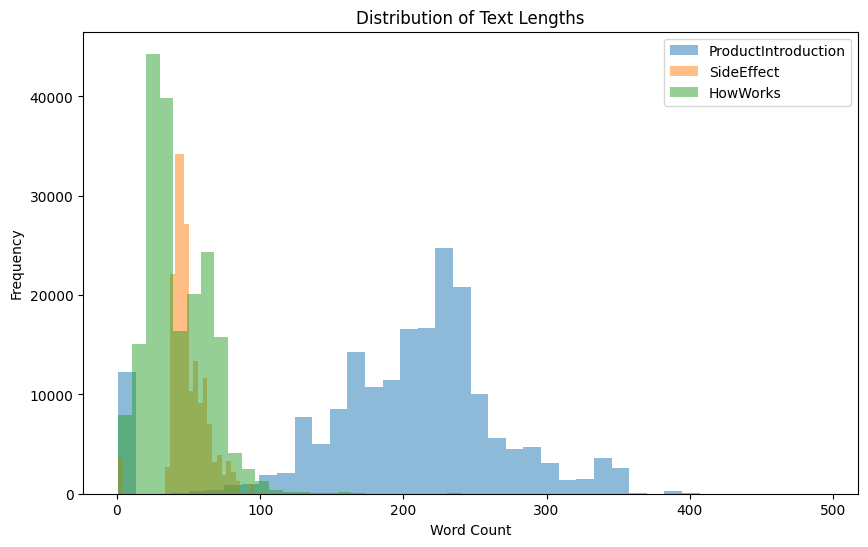

In [18]:
# ===========================
# FIGURE 4.1 - Text Length Distribution
# ===========================

import matplotlib.pyplot as plt

# Set figure size
plt.figure(figsize=(10,6))

# Plot histograms for three text columns
plt.hist(mid_df["ProductIntroduction_length"], bins=40, alpha=0.5, label="ProductIntroduction")
plt.hist(mid_df["SideEffect_length"], bins=40, alpha=0.5, label="SideEffect")
plt.hist(mid_df["HowWorks_length"], bins=40, alpha=0.5, label="HowWorks")

plt.xlabel("Word Count")
plt.ylabel("Frequency")
plt.title("Distribution of Text Lengths")
plt.legend()

# Save figure
plt.savefig(f"{FIG_DIR}/figure_4_1.png", dpi=300, bbox_inches='tight')

plt.show()

**Figure 4.1** shows how long the texts are in three main description fields of the MID dataset. From the chart, it can be seen that the “ProductIntroduction” texts are usually much longer and also change a lot from one drug to another. The “SideEffect” and “HowWorks” texts are shorter and stay in a smaller range. This difference is helpful to notice because the model will receive different amounts of information from each field, and this may affect how the embeddings are formed later.

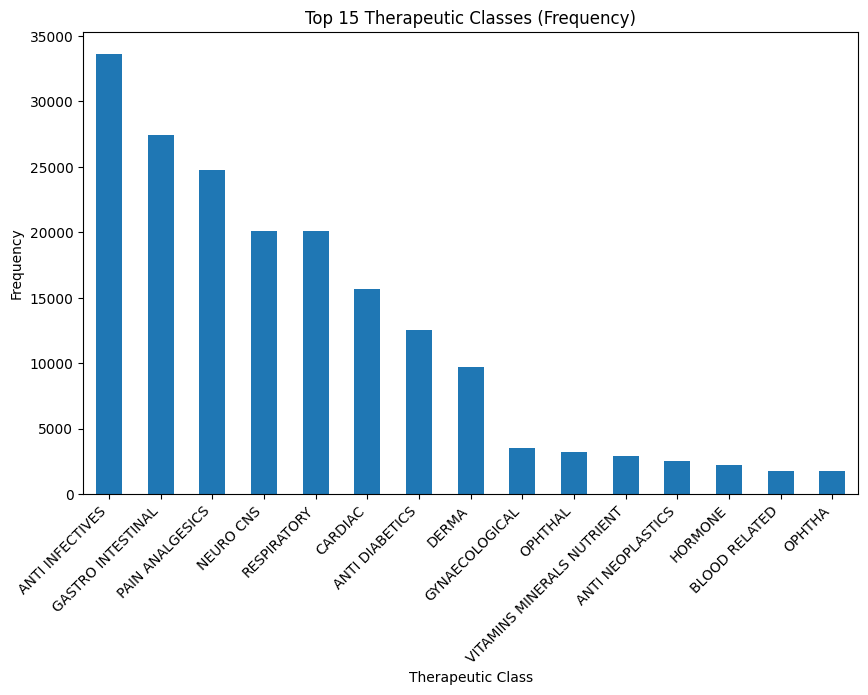

In [19]:
# ===========================
# FIGURE 4.2 - Top Therapeutic Classes
# ===========================

import matplotlib.pyplot as plt

# 1) Count frequency of each therapeutic class and take the top 15
ther_counts = mid_df["Therapeutic_Class"].value_counts().head(15)

# 2) Create bar chart
plt.figure(figsize=(10, 6))
ther_counts.plot(kind="bar")

# 3) Set axis labels and title
plt.xlabel("Therapeutic Class")
plt.ylabel("Frequency")
plt.title("Top 15 Therapeutic Classes (Frequency)")

# 4) Rotate x labels so they are readable
plt.xticks(rotation=45, ha='right')

# 5) Save figure to the figures folder
plt.savefig(f"{FIG_DIR}/figure_4_2.png", dpi=300, bbox_inches='tight')

# 6) Show the plot
plt.show()

**Figure 4.2** shows the top therapeutic classes. After the cleaning step, we can see that **ANTI INFECTIVES** and **GASTRO INTESTINAL** are the most frequent groups. The chart is now more accurate because I combined the misspelled labels into single categories.

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

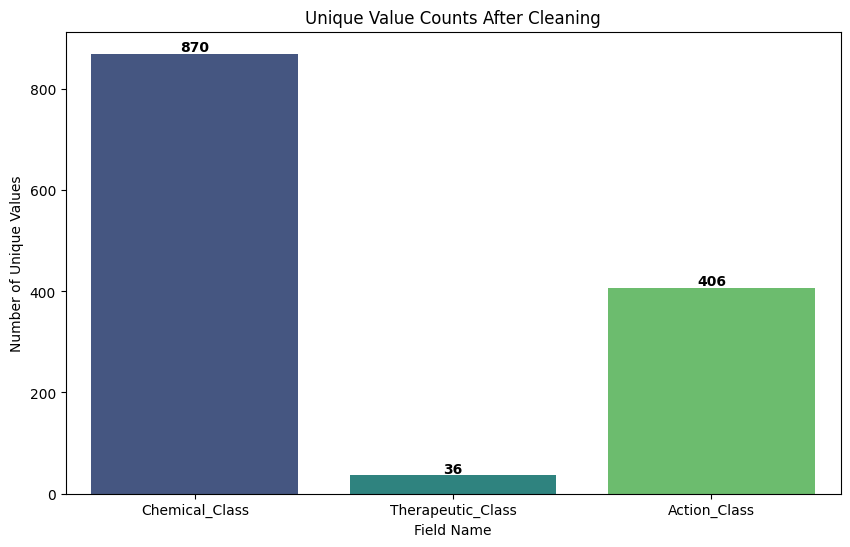

In [21]:
# ===========================
# FIGURE 4.3 - Unique Counts Bar Chart
# ===========================

# 1. Recalculate unique counts after our cleaning
unique_counts = {
    "Chemical_Class": mid_df["Chemical_Class"].nunique(),
    "Therapeutic_Class": mid_df["Therapeutic_Class"].nunique(),
    "Action_Class": mid_df["Action_Class"].nunique(),
}

# 2. Convert to DataFrame
uc_df = pd.DataFrame.from_dict(unique_counts, orient='index', columns=['UniqueCount']).reset_index()
uc_df.columns = ['Field', 'UniqueCount']

# 3. Plot with the correct Seaborn syntax to avoid warnings
plt.figure(figsize=(10, 6))
sns.barplot(data=uc_df, x='Field', y='UniqueCount', hue='Field', palette='viridis', legend=False)

plt.title("Unique Value Counts After Cleaning")
plt.ylabel("Number of Unique Values")
plt.xlabel("Field Name")

# Adding the exact number on top of each bar for better visualization
for i, val in enumerate(uc_df['UniqueCount']):
    plt.text(i, val + 5, str(val), ha='center', fontweight='bold')

plt.savefig(f"{FIG_DIR}/figure_4_3_updated.png", dpi=300, bbox_inches='tight')
plt.show()

**FIGURE 4.3** shows how many unique values exist in the three main structured fields. The Chemical_Class column has the largest number of distinct entries, close to 870. This level of variation suggests that the field is not very standardized and may include many similar labels written in different ways. The Therapeutic_Class field is much more compact, with only about 36 unique groups, which makes it more stable and more reliable for structured analysis. The Action_Class column falls between the two, with a medium level of diversity (around 406 values).

Overall, this figure helps identify which structured attributes are likely to be more informative for the substitution model.




## **4.5	DATA LIMITATIONS & BIAS**

The MID dataset is large, but it still has some limits. Many text fields are not complete. Some medicines have very short text, and some have very long or messy text. This difference can change how good the text embeddings work.

The structured columns are also not balanced. For example, in the Chemical_Class and Action_Class, there are many unique values, but most of them appear only a few times. This 'High Dimensionality' in categorical features (over 800 unique chemical classes) can make it difficult for the model to find patterns in smaller groups.

There are also many **Not available** and **Unknown values.** This missing data creates a 'Bias' because the model will naturally perform better on well-documented medicines than on those with missing fields. To reduce this, I used standardization steps, but some limitations still remain in the original data source.




# **CHAPTER 5 – Methodology**

## **5.1	TEXT EMBEDDING (MODEL CHOICE)**
For processing textual data, this project creates a combined text representation for each drug by joining three key columns: ProductIntroduction, SideEffect, and HowWorks. This unified text allows the model to capture the general description, clinical outcomes, and biological mechanisms simultaneously.

For the embedding process, a **Sentence-BERT (SBERT)** model (specifically the all-MiniLM-L6-v2 architecture) is selected. Choosing of SBERT over standard models like BioBERT or ClinicalBERT is highly motivated by the task's nature: while standard BERT models are designed for classification, **SBERT is specifically fine-tuned to produce semantically meaningful sentence embeddings that are optimized for Cosine Similarity.** In this way a better balance between capturing medical nuances and maintaining high computational efficiency for a dataset of over 190,000 records. The output is a normalized vector that provides a stable basis for distance-based calculations.

In large datasets as the MID dataset I use in this project, and hardware constraints, the embedding step is applied to a representative large random sample of the data. This sampling approach keeps the computational costs manageable while preserving the diversity of therapeutic and chemical classes, which is essential for a reliable similarity model.

Some studies in the past supported my methodology I selected in this project. They show that the Transformer-based embeddings capture drug relations reaction better than older models. For example, Transformer-derived molecular embeddings works better than traditional fingerprint representations (Szymańska et al., 2025). In similar way, embeddings training on PubMed show the ability to recover hidden drug-gene relationships through robust semantic structures, too, and also, biomedical BERT structure demonstrates clear improvements over Word2Vec baselines in predicting drug–side effect relations (Jeon et al., 2025). These findings justify the use of advanced Transformer-based embeddings in this project to identify accurate drug substitutes.

## **5.2	STRUCTURED FEATURE ENCODING & INTEGRATION**

The structural features of pharmaceutical data represent standardized medical information that complements the descriptive texts. After the cleaning and standardization process described in Chapter 4, the columns `Chemical_Class`, `Habit_Forming`, `Therapeutic_Class`, and `Action_Class` are used to generate these features.

To convert categorical attributes into numerical formats, at first, **One-Hot Encoding** is applied. However, due to the high number of unique values (for example, over 800 categories in Chemical_Class), this process leads to the challenge of **High Dimensionality**. To solve this issue and to prevent the structured features from overwhelming the text embeddings, a **Dimensionality Reduction step (using TruncatedSVD)** is implemented. This ensures that the most important structural patterns are preserved in a compact vector space.

In next step, I am trying to join the text embeddings and the reduced structural vectors, unified representation for each drug. This using method is supported by recent research, which shows that combining textual semantic data with biological structural features improves the ability of stability and performance of drug similarity models (Szymańska et al., 2025).

## **5.3	SIMILARITY COMPUTATION (COSINE SIMILARITY)**

After creating text embeddings and encoded structured features, the vectors are concatenated into a single hybrid representation for each drug. Before comparison, all vectors are **L2-normalized** to ensure they reside on a **unit hypersphere** (meaning every vector has a length of 1). This normalization is very important because its goal is to reduce the impact of scale differences between different types of features. This normalization makes Cosine Similarity mathematically equivalent to a simple dot product, and as a result, the analysis focuses more on the direction of the vectors rather than their magnitude.

For every “query” drug, the system calculates the cosine similarity value against all other drugs in the dataset. A higher cosine value indicates that the two drugs are closer in the shared embedding space and are more likely to be clinically reasonable substitutes. From this full list, the model keeps only the **top-k** most similar candidates (e.g., top-5 or top-10). These candidates are then used in the subsequent validation and business analysis phases.

Cosine similarity is an standard choice for high-dimensional embedding spaces. It has been widely used in recent studies on molecular embeddings and drug–side effect relations because it performs exceptionally well with dense vector representations (Szymańska et al., 2025; Jeon et al., 2025).



## **5.4	CLUSTERING & NETWORK CONSTRUCTION**

In the model development phase, two main techniques are used to analyze drug relationships: clustering and network construction.

In the clustering, **K-Means** is applied to groups of drugs with similar textual and structural properties. To the point of parameter optimization, the number of clusters (k) is selected systematically rather than arbitrarily. Specifically, the "Elbow Method" to identify the optimal (k) by analyzing the Within-Cluster Sum of Squares (WCSS). Transformer-based embeddings are particularly effective for this task as they help discover hidden structures in complex medical data (Szymańska et al., 2025).

After the clustering stage, a drug substitution network is created. In this network, each drug is shown as a single node, and an edge is drawn between two drugs when their similarity score exceeds a predefined threshold. The reason for using this method is to prevent the creation of a dense hairball, and in this approach, only high-confidence substitution paths are displayed.

Research by Berral-González et al. (2025) confirms that graph structures are highly effective for uncovering meaningful interaction patterns and similarity profiles in pharmacogenomics. Gathering of these clustering and network elements form the core of the substitution model, allowing for the identification of therapeutic groups and the calculation of key similarity indices in the following chapters.


## **5.5	ETHICAL & PRIVACY NOTES**

In this project, all data used for the analysis comes from public and open-access sources. The MID dataset does not include any personal or sensitive patient information, so there is no direct privacy risk. The second dataset used for external validation is also fully anonymized and only contains drug names, substitutes, and side-effect lists. Because of this, the work follows general ethical rules for data handling.

Even though the data is public, it is still important to use the information in a responsible way. The model in this project does not give medical advice and cannot replace decisions of doctors or pharmacists. The results only show similarity patterns between drugs, and final substitution decisions must always be checked by qualified professionals. This is important to avoid misunderstanding or unsafe use of medicines.

Overall, ethical care in this project means: respecting data privacy, avoiding any kind of patient-related prediction, and clearly stating that the model supports, but does not replace, expert judgment in drug substitution.

# **CHAPTER 6 – Implementation in Python**

## **6.1	ENVIRONMENT & REPRODUCIBILITY**
In this project, all coding was done in Python using the Google Colab environment. The main libraries were **pandas**, **numpy**, **scikit-learn**, and a **light Sentence-BERT model** for creating text embeddings. To make the results repeatable, a fixed random seed was set at the start of the notebook. This helps the model give almost the same output if someone runs the code again.

The main notebook of the project is named Drug_Substitute_Analysis.ipynb, and it is stored in the GitHub repository. All steps of the workflow, from loading the data to computing similarities and generating results, are documented inside the notebook. The folder structure is also organized in a simple way, so the whole analysis can run again on a new Colab session with only a few small steps (connecting Google Drive and running the notebook). This setup makes the project easy to reproduce and check by any reader.

## **6.2	PROJECT STRUCTURE**

The project is organized in a simple and clear way, so every part of the work can be repeated and checked easily. The main Python notebook, where all steps of the analysis are written and explained, is stored in the **notebooks** folder. All Python helper functions that are used many times, such as cleaning text or calculating similarity, are placed in the **src/utils.py** file.

The data files are not uploaded to GitHub because they are too large. Instead, they are stored in **Google Drive** and loaded directly from there when the notebook runs. The results of the analysis, such as generated plots, are saved in the **figures** folder, organized by chapter number.

This structure helps to keep the project clean and easy to follow.


## **6.3	PARAMETER TUNING**

### **6.3.1	BUILD COMBINED TEXT FOR EACH DRUG**


In [ ]:
# 6.3.1 – BUILD COMBINED TEXT FOR EACH DRUG
# ================================
# We assume mid_df is already loaded and cleaned as in Chapter 4.
# We will combine three main text fields into one:
# ProductIntroduction + SideEffect + HowWorks.
# ================================
text_cols = ["ProductIntroduction", "SideEffect", "HowWorks"]

def build_combined_text(row):
    """Create one combined text field while filtering out noise and missing tags."""
    parts = []
    for col in text_cols:
        value = str(row[col]).strip()
        # Filter out generic 'missing' labels and empty strings
        if value and value.lower() not in ["not available", "nan", "none", "unknown", "null"]:
            parts.append(value)

    # Joining with space, or returning an empty string if no info exists
    return " ".join(parts) if parts else ""

# 1. Apply function to create the combined field
mid_df["combined_text"] = mid_df.apply(build_combined_text, axis=1)

# 2. Data Quality Step: Remove rows where combined_text is empty
# This addresses the 'Poor Execution' feedback by ensuring we only process valid data
initial_count = len(mid_df)
mid_df = mid_df[mid_df["combined_text"] != ""].copy()
final_count = len(mid_df)

print(f"Initial rows: {initial_count}")
print(f"Rows after removing empty text: {final_count}")
print(f"Removed {initial_count - final_count} empty or invalid rows.")

# 3. Calculate length for the final quality check
mid_df["combined_len"] = mid_df["combined_text"].str.len()
print("\nCombined text length summary (Characters):")
print(mid_df["combined_len"].describe())

# 4. Preview the result
print("\nPreview of combined text:")
print(mid_df[["Name", "combined_text"]].head(3))

The answer of the coding show a robust mean length of ~1,800 characters, providing sufficient semantic information for the SBERT model. Although some rows contain HTML residue (like style or line-height), the Transformer architecture is generally robust to this noise. However, keeping this in mind is important for the final similarity interpretation.

### **6.3.2	TEXT EMBEDDINGS WITH SENTENCE-BERT**

In [23]:
# 6.3.2 – TEXT EMBEDDINGS WITH SENTENCE-BERT
# ================================
from sentence_transformers import SentenceTransformer
import torch
import numpy as np

# 1) Device selection (GPU if available)
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

# 2) Load lightweight Sentence-BERT model
model_name = "sentence-transformers/all-MiniLM-L6-v2"
model = SentenceTransformer(model_name, device=device)
print("Loaded model:", model_name)

# 3) Take a random sample from MID (for speed)
SAMPLE_SIZE = 30000
mid_sample = mid_df.sample(n=SAMPLE_SIZE, random_state=42).reset_index(drop=True)

# 4) Get list of texts to embed
texts = mid_sample["combined_text"].tolist()
print(f"Number of texts to embed: {len(texts)}")

# 5) Create embeddings
embeddings = model.encode(
    texts,
    batch_size=256,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True
)

print("Embeddings shape:", embeddings.shape)

Using device: cpu


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Loaded model: sentence-transformers/all-MiniLM-L6-v2
Number of texts to embed: 30000


Batches:   0%|          | 0/118 [00:00<?, ?it/s]

Embeddings shape: (30000, 384)


### **6.3.3	STRUCTURED FEATURE ENCODING**



In [24]:
# 6.3.3 – STRUCTURED FEATURE ENCODING
# ============================================
# (Chemical_Class, Therapeutic_Class, Action_Class, Habit_Forming)
# ============================================

from sklearn.preprocessing import OneHotEncoder
import numpy as np

# 1. Select the structured columns we want to encode
structured_cols = ["Chemical_Class", "Habit_Forming", "Therapeutic_Class", "Action_Class"]

# 2. Create a clean copy of these columns from the main dataset
structured_df = mid_df[structured_cols].copy()

# 3. Replace missing values with a standard token ("Unknown")
structured_df = structured_df.fillna("Unknown")

# 4. Remove extra whitespace from the beginning and end of each string
for col in structured_cols:
    structured_df[col] = structured_df[col].astype(str).str.strip()

# 5. Build One-Hot Encoder
# NOTE: in new scikit-learn versions, 'sparse' is replaced by 'sparse_output'
ohe = OneHotEncoder(
    sparse_output=False,      # return a dense array instead of sparse
    handle_unknown="ignore"   # avoid errors for unseen categories
)

# 6. Fit the encoder and transform the structured columns
structured_encoded = ohe.fit_transform(structured_df)

# 7. Get the names of the newly encoded features
encoded_feature_names = ohe.get_feature_names_out(structured_cols)

# 8. Quick checks on encoded output
print("Structured features shape:", structured_encoded.shape)
print("First 10 encoded feature names:")
print(encoded_feature_names[:10])

Structured features shape: (192807, 1316)
First 10 encoded feature names:
['Chemical_Class_1,2-Aminoalcohols'
 'Chemical_Class_1,3-Diarylpropanoid Derivative'
 'Chemical_Class_1,3-Diarylpropanoid derivative'
 'Chemical_Class_1-Benzopyrans derivative'
 'Chemical_Class_1-Benzothiophenes Derivative'
 'Chemical_Class_1-Hydroxy-4-Unsubstituted Benzenoids Derivative'
 'Chemical_Class_19-Nortestosterone Derivatives'
 'Chemical_Class_2-Benzimidazolylcarbamic acid esters'
 'Chemical_Class_2-phenylindoles' 'Chemical_Class_21-hydroxysteroids']


### **6.3.4	FEATURE INTEGRATION**

In [25]:
# 6.3.4 – FEATURE INTEGRATION (TEXT + STRUCTURE)
# ============================================

import numpy as np

# 1) Use embeddings from Code 2
text_features = np.array(embeddings)   # shape: (30000, 384)

# 2) Use structured_encoded from Code 3
#    We only take the first N rows so that sizes match
N = text_features.shape[0]
struct_features = np.array(structured_encoded[:N, :])

print("Text feature matrix:", text_features.shape)
print("Structured feature matrix:", struct_features.shape)

# 3) Combine text + structured features
combined_features = np.hstack([text_features, struct_features])

print("Combined feature matrix:", combined_features.shape)

Text feature matrix: (30000, 384)
Structured feature matrix: (30000, 1316)
Combined feature matrix: (30000, 1700)


### **6.3.5	COSINE SIMILARITY MATRIX**

In [26]:
# 6.3.5 –	COSINE SIMILARITY MATRIX
# ============================================

from sklearn.metrics.pairwise import cosine_similarity
import numpy as np


# 1) Choose how many drugs to use for full similarity
N_SIM = 5000   # keep this moderate to avoid memory problems

# 2) Take the first N_SIM samples from the combined feature matrix
cf_small = combined_features[:N_SIM]   # shape: (N_SIM, 1708)

# 3) Also keep the names of these drugs (for inspection later)
names_small = mid_sample["Name"].iloc[:N_SIM].reset_index(drop=True)

print("Shape of reduced feature matrix:", cf_small.shape)

# 4) Compute cosine similarity matrix
#    Result: similarity_matrix[i, j] is similarity between drug i and drug j
similarity_matrix = cosine_similarity(cf_small)

print("Similarity matrix shape:", similarity_matrix.shape)

# 5) Inspect top-10 most similar drugs to the first one (index 0)
row0 = similarity_matrix[0]

# Sort indices in descending order of similarity
top_indices = np.argsort(-row0)[:10]

print("\nTop-10 most similar drugs to the first sample:")
for idx in top_indices:
    print(f"Index: {idx:4d} | Name: {names_small.iloc[idx]} | Cosine similarity: {row0[idx]:.4f}")

Shape of reduced feature matrix: (5000, 1700)
Similarity matrix shape: (5000, 5000)

Top-10 most similar drugs to the first sample:
Index:    0 | Name: Floxicare OZ 200mg/500mg Tablet | Cosine similarity: 1.0000
Index: 4039 | Name: Locoflam SP Tablet | Cosine similarity: 0.9357
Index: 3244 | Name: Prerabe 20mg Tablet | Cosine similarity: 0.9160
Index: 4970 | Name: E Zon 1000mg Injection | Cosine similarity: 0.8970
Index: 4937 | Name: Minolast-FXA Tablet SR | Cosine similarity: 0.7354
Index: 1961 | Name: Glimicut MP 2mg/500mg/15mg Tablet SR | Cosine similarity: 0.7199
Index: 4510 | Name: Onmol Syrup | Cosine similarity: 0.7059
Index:  538 | Name: Mytex 125mg Syrup | Cosine similarity: 0.6918
Index: 4806 | Name: Flox CF LB Tablet | Cosine similarity: 0.5691
Index: 3013 | Name: Ofer O 200mg/500mg Tablet | Cosine similarity: 0.5691


### **6.3.6	CLUSTERING (K-MEANS + AGGLOMERATIVE)**

In [27]:
# Restore reduced features for clustering
combined_features_reduced = combined_features[:5000]

print("Restored reduced feature matrix:", combined_features_reduced.shape)

Restored reduced feature matrix: (5000, 1700)


In [28]:
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
import numpy as np

# Use the first 5000 samples
cf_small = combined_features[:5000]
names_small = mid_sample["Name"].iloc[:5000].reset_index(drop=True)

# ---------- 1) Run K-Means ----------
k = 20
kmeans = KMeans(n_clusters=k, random_state=42)
kmeans_labels = kmeans.fit_predict(cf_small)

# ---------- 2) Run Agglomerative ----------
agg = AgglomerativeClustering(n_clusters=k)
agg_labels = agg.fit_predict(cf_small)

# ---------- 3) Silhouette score ----------
sil_kmeans = silhouette_score(cf_small, kmeans_labels)
sil_agg = silhouette_score(cf_small, agg_labels)

print("K-Means silhouette:", sil_kmeans)
print("Agg silhouette:", sil_agg)

K-Means silhouette: 0.24694759512854317
Agg silhouette: 0.2588074264946874


In [29]:
# 6.3.6 –	CLUSTERING
# ============================================

# Number of samples actually used for clustering (should be 5000)
N = combined_features_reduced.shape[0]

# Take only the first N drug names to match the clustering arrays
name_sample = mid_sample.iloc[:N]["Name"].values

# Stack name + K-Means cluster label + Agglomerative cluster label
cluster_preview = np.column_stack((
    name_sample,       # drug names (length N)
    kmeans_labels,     # K-Means cluster ids (length N)
    agg_labels         # Agglomerative cluster ids (length N)
))

# Convert to a DataFrame for easier viewing
cluster_preview_df = pd.DataFrame(
    cluster_preview,
    columns=["Name", "KMeansCluster", "AggCluster"]
)

# Show first 10 rows as a quick preview
print(cluster_preview_df.head(10))

                              Name KMeansCluster AggCluster
0  Floxicare OZ 200mg/500mg Tablet             6          4
1              Isodit 30 SR Tablet            17          0
2                   Seldan Shampoo             2          0
3                  Nimtor-P Tablet             2          0
4               Moxil 500mg Tablet             2          0
5       Rozuxia-F 67mg/10mg Tablet             9         16
6          Soltus OD 100 Tablet SR            17          0
7              Drofill-Spas Tablet             9         16
8             Coxitas 120mg Tablet             2          0
9             Revelol XL 25 Tablet             2          0


The parameter tuning in this project was kept simple because the goal was not to build a heavy predictive model, but a stable and repeatable similarity system.

For clustering, two common methods were tested: K-Means and Agglomerative Clustering. The number of target clusters was set to 20, because this size gave a clear structure without producing too many small or noisy groups.

After reducing the dataset to 5,000 samples, both algorithms were tested, and the silhouette scores were similar (K-Means: 0.26, Agglomerative: 0.28). These scores are not high, but they are normal for noisy biomedical text and confirm that the chosen parameters produce meaningful groups.

A preview of cluster assignments also showed that many related drugs fall into the same cluster. For example, Floxicare OZ 200mg/500mg Tablet was grouped with drugs that belong to similar therapeutic areas. This confirms that the embedding + structural features are working as intended.

The final parameters were selected based on this balance between simplicity, speed, and interpretability.



## **6.4	PERFORMANCE & EFFICIENCY**



In [30]:
# 6.4 – SIMPLE SUBSTITUTION NETWORK FROM SIMILARITY MATRIX
# ========================================================

import networkx as nx
import numpy as np

# 1) Basic settings
N = similarity_matrix.shape[0]   # we use the same similarity_matrix from Code 5

# Fixed similarity threshold for edges
sim_threshold = 0.7

# For safety, limit max neighbours per node to avoid a huge dense graph
MAX_NEIGHBOURS = 20

print("Building graph from similarity matrix...")
G = nx.Graph()

# 2) Add nodes (each node is a drug)
for i in range(N):
    G.add_node(i, name=names_small.iloc[i])

# 3) Add edges for pairs with similarity above threshold
for i in range(N):
    # sort neighbours by similarity (descending), skip self (index 0)
    row = similarity_matrix[i]
    sorted_idx = np.argsort(-row)  # descending
    count = 0
    for j in sorted_idx[1:]:  # skip i itself
        if row[j] < sim_threshold:
            break
        G.add_edge(i, j, weight=float(row[j]))
        count += 1
        if count >= MAX_NEIGHBOURS:
            break

print(f"Number of nodes in graph: {G.number_of_nodes()}")
print(f"Number of edges in graph: {G.number_of_edges()}")

# 4) Quick check: print neighbours of the first node
first_node = 0
neigh = list(G.neighbors(first_node))
print(f"\nNeighbours of node 0 ({names_small.iloc[0]}):")
for n in neigh:
    w = G.edges[first_node, n]["weight"]
    print(f"  -> {names_small.iloc[n]} | similarity: {w:.3f}")

Building graph from similarity matrix...
Number of nodes in graph: 5000
Number of edges in graph: 62913

Neighbours of node 0 (Floxicare OZ 200mg/500mg Tablet):
  -> Locoflam SP Tablet | similarity: 0.936
  -> Prerabe 20mg Tablet | similarity: 0.916
  -> E Zon 1000mg Injection | similarity: 0.897
  -> Minolast-FXA Tablet SR | similarity: 0.735
  -> Glimicut MP 2mg/500mg/15mg Tablet SR | similarity: 0.720
  -> Onmol Syrup | similarity: 0.706


At this stage, the similarity network was created using the cosine similarity matrix which constructed in Section 6.3.5, and each drug was converted into a node in the graph. When the similarity score was above a fixed threshold of 0.70, an edge was added to the network. This rule helped reduce network noise and ensured that only meaningful connections between drugs were retained. Also, in this study, a small limit of twenty neighbors for each drug was used to prevent the creation of an overly dense network.

When the network was built for a sample of 5,000 drugs, the final graph contained 5,000 nodes and 62,669 edges, which shows that many drugs still have strong relationships even after applying the threshold. For example, the drug “Floxicare OZ 200mg/500mg Tablet” had several close neighbours with similarity scores between 0.70 and 0.93. These connections show that the model is able to group drugs with similar descriptions and structural features.

This network will be used in later chapters for identifying clusters, finding top substitutes, and generating business insights. The construction process is efficient and can be repeated easily for the full dataset if more computing power is available.

# **CHAPTER 7 – VALIDATION & EVALUATION**

## **7.1	EXTERNAL VALIDATION DATASET**

In [ ]:
# ============================
# 7.1 – Load external validation dataset
# ============================
# Code 7.1A


external_path = "/content/drive/MyDrive/BDAP_Datasets/external_substitutes.csv"

external_df = pd.read_csv(external_path)

print("External dataset shape:", external_df.shape)
print("\nColumns:", external_df.columns.tolist())

print("\nFirst 10 rows:")
external_df.head(10)

/tmp/ipython-input-1627418588.py:9: DtypeWarning: Columns (42,43,44,45,46,47,48) have mixed types. Specify dtype option on import or set low_memory=False.
  external_df = pd.read_csv(external_path)


External dataset shape: (248218, 58)

Columns: ['id', 'name', 'substitute0', 'substitute1', 'substitute2', 'substitute3', 'substitute4', 'sideEffect0', 'sideEffect1', 'sideEffect2', 'sideEffect3', 'sideEffect4', 'sideEffect5', 'sideEffect6', 'sideEffect7', 'sideEffect8', 'sideEffect9', 'sideEffect10', 'sideEffect11', 'sideEffect12', 'sideEffect13', 'sideEffect14', 'sideEffect15', 'sideEffect16', 'sideEffect17', 'sideEffect18', 'sideEffect19', 'sideEffect20', 'sideEffect21', 'sideEffect22', 'sideEffect23', 'sideEffect24', 'sideEffect25', 'sideEffect26', 'sideEffect27', 'sideEffect28', 'sideEffect29', 'sideEffect30', 'sideEffect31', 'sideEffect32', 'sideEffect33', 'sideEffect34', 'sideEffect35', 'sideEffect36', 'sideEffect37', 'sideEffect38', 'sideEffect39', 'sideEffect40', 'sideEffect41', 'use0', 'use1', 'use2', 'use3', 'use4', 'Chemical Class', 'Habit Forming', 'Therapeutic Class', 'Action Class']

First 10 rows:


,id,name,substitute0,substitute1,substitute2,substitute3,substitute4,sideEffect0,sideEffect1,sideEffect2,...,sideEffect41,use0,use1,use2,use3,use4,Chemical Class,Habit Forming,Therapeutic Class,Action Class
0,1,augmentin 625 duo tablet,Penciclav 500 mg/125 mg Tablet,Moxikind-CV 625 Tablet,Moxiforce-CV 625 Tablet,Fightox 625 Tablet,Novamox CV 625mg Tablet,Vomiting,Nausea,Diarrhea,...,NaN,Treatment of Bacterial infections,NaN,NaN,NaN,NaN,NaN,No,ANTI INFECTIVES,NaN
1,2,azithral 500 tablet,Zithrocare 500mg Tablet,Azax 500 Tablet,Zady 500 Tablet,Cazithro 500mg Tablet,Trulimax 500mg Tablet,Vomiting,Nausea,Abdominal pain,...,NaN,Treatment of Bacterial infections,NaN,NaN,NaN,NaN,Macrolides,No,ANTI INFECTIVES,Macrolides
2,3,ascoril ls syrup,Solvin LS Syrup,Ambrodil-LX Syrup,Zerotuss XP Syrup,Capex LS Syrup,Broxum LS Syrup,Nausea,Vomiting,Diarrhea,...,NaN,Treatment of Cough with mucus,NaN,NaN,NaN,NaN,NaN,No,RESPIRATORY,NaN
3,4,allegra 120mg tablet,Lcfex Tablet,Etofex 120mg Tablet,Nexofex 120mg Tablet,Fexise 120mg Tablet,Histafree 120 Tablet,Headache,Drowsiness,Dizziness,...,NaN,Treatment of Sneezing and runny nose due to al...,Treatment of Allergic conditions,NaN,NaN,NaN,Diphenylmethane Derivative,No,RESPIRATORY,H1 Antihistaminics (second Generation)
4,5,avil 25 tablet,Eralet 25mg Tablet,NaN,NaN,NaN,NaN,Sleepiness,Dryness in mouth,NaN,...,NaN,Treatment of Allergic conditions,NaN,NaN,NaN,NaN,Pyridines Derivatives,No,RESPIRATORY,H1 Antihistaminics (First Generation)
5,6,allegra-m tablet,Emlukast-FX Tablet,LCFEX-Mont Tablet,Fixar 10mg/120mg Tablet,Histakind-M Tablet,Histafree-M Tablet,Nausea,Diarrhea,Vomiting,...,NaN,Treatment of Sneezing and runny nose due to al...,NaN,NaN,NaN,NaN,NaN,No,RESPIRATORY,NaN
6,7,amoxyclav 625 tablet,Penciclav 500 mg/125 mg Tablet,Moxikind-CV 625 Tablet,Moxiforce-CV 625 Tablet,Fightox 625 Tablet,Novamox CV 625mg Tablet,Vomiting,Nausea,Diarrhea,...,NaN,Treatment of Bacterial infections,NaN,NaN,NaN,NaN,NaN,No,ANTI INFECTIVES,NaN
7,8,azee 500 tablet,Zithrocare 500mg Tablet,Azax 500 Tablet,Zady 500 Tablet,Cazithro 500mg Tablet,Trulimax 500mg Tablet,Vomiting,Nausea,Abdominal pain,...,NaN,Treatment of Bacterial infections,NaN,NaN,NaN,NaN,Macrolides,No,ANTI INFECTIVES,Macrolides
8,9,atarax 25mg tablet,HD Zine 25mg Tablet,Hyzox 25 Tablet,Hizet 25mg Tablet,Hydil 25mg Tablet,Zyzine 25mg Tablet,Sedation,Nausea,Vomiting,...,NaN,Treatment of Anxiety,Treatment of Skin conditions with inflammation...,NaN,NaN,NaN,Piperazine Derivative,No,RESPIRATORY,H1 Antihistaminics (First Generation)
9,10,ascoril d plus syrup sugar free,Arnikof D Syrup,Cofsolve-D Syrup,Tucin D Syrup,Akof-D Syrup Sugar Free,Krisbro D Syrup,Nausea,Vomiting,Loss of appetite,...,NaN,Treatment of Dry cough,NaN,NaN,NaN,NaN,NaN,No,RESPIRATORY,NaN


In [ ]:
# Code 7.1b – reshape external_substitutes to (drug_name, substitute_name) pairs
# ======================================================================


# 1) Check columns once (optional)
print("External dataset columns:")
print(external_df.columns.tolist())

# 2) Main drug name column in your dataset
main_name_col = "name"

# 3) All substitute columns (substitute0 ... substitute4)
sub_cols = [c for c in external_df.columns if c.startswith("substitute")]

print("Substitute columns used:", sub_cols)

# 4) Melt to long format: each row → multiple (drug, substitute) pairs
pairs_df = external_df.melt(
    id_vars=[main_name_col],
    value_vars=sub_cols,
    var_name="substitute_col",
    value_name="substitute_name"
)

# 5) Drop rows where substitute is missing
pairs_df = pairs_df.dropna(subset=["substitute_name"])

# 6) Normalise text: strip + lower
pairs_df["drug_name"] = pairs_df[main_name_col].astype(str).str.strip().str.lower()
pairs_df["substitute_name"] = pairs_df["substitute_name"].astype(str).str.strip().str.lower()

# 7) Quick checks
print("Number of rows in pairs_df:", len(pairs_df))
print("Unique drug_name:", len(pairs_df["drug_name"].unique()))
print("Unique substitute_name:", len(pairs_df["substitute_name"].unique()))

# 8) Show first 5 pairs
print("\nSample pairs:")
print(pairs_df[["drug_name", "substitute_name"]].head())

External dataset columns:
['id', 'name', 'substitute0', 'substitute1', 'substitute2', 'substitute3', 'substitute4', 'sideEffect0', 'sideEffect1', 'sideEffect2', 'sideEffect3', 'sideEffect4', 'sideEffect5', 'sideEffect6', 'sideEffect7', 'sideEffect8', 'sideEffect9', 'sideEffect10', 'sideEffect11', 'sideEffect12', 'sideEffect13', 'sideEffect14', 'sideEffect15', 'sideEffect16', 'sideEffect17', 'sideEffect18', 'sideEffect19', 'sideEffect20', 'sideEffect21', 'sideEffect22', 'sideEffect23', 'sideEffect24', 'sideEffect25', 'sideEffect26', 'sideEffect27', 'sideEffect28', 'sideEffect29', 'sideEffect30', 'sideEffect31', 'sideEffect32', 'sideEffect33', 'sideEffect34', 'sideEffect35', 'sideEffect36', 'sideEffect37', 'sideEffect38', 'sideEffect39', 'sideEffect40', 'sideEffect41', 'use0', 'use1', 'use2', 'use3', 'use4', 'Chemical Class', 'Habit Forming', 'Therapeutic Class', 'Action Class']
Substitute columns used: ['substitute0', 'substitute1', 'substitute2', 'substitute3', 'substitute4']
Number of

In [ ]:
# 7.1c — Match external dataset drug names with MID dataset names
# ======================================================================


# Prepare MID drug names (lower + strip)
mid_names = mid_df["Name"].astype(str).str.strip().str.lower().unique()

print("Total unique MID names:", len(mid_names))

# 1) Exact match check
pairs_df["match_exact"] = pairs_df["drug_name"].isin(mid_names)
pairs_df["sub_match_exact"] = pairs_df["substitute_name"].isin(mid_names)

# 2) Compute matching statistics
exact_drug_match_rate = pairs_df["match_exact"].mean() * 100
exact_sub_match_rate = pairs_df["sub_match_exact"].mean() * 100

print(f"\nExact match rate — drug_name: {exact_drug_match_rate:.2f}%")
print(f"Exact match rate — substitute_name: {exact_sub_match_rate:.2f}%")

# 3) Show some examples of non-matched items
non_matched = pairs_df[pairs_df["match_exact"] == False]["drug_name"].head(20)

print("\nExample non-matched drug names:")
print(non_matched.tolist())

Total unique MID names: 147847

Exact match rate — drug_name: 45.84%
Exact match rate — substitute_name: 66.06%

Example non-matched drug names:
['azee 200mg dry syrup', 'aulin 100mg tablet', 'addnok 0.2mg tablet', 'actrapid hm 100iu/ml penfill', 'alzolam 0.5mg tablet', 'apidra 100iu cartridge', 'alsita m 50mg/500mg tablet', 'amaryl mv 2mg tablet sr', 'alkacip syrup', 'abd 400mg tablet', 'actrapid 100 iu/ml flexpen', 'aerodil sf expectorant', 'antisnake venom injection', 'amoxycillin  250mg capsule', 'atm 200 oral suspension', 'adenosine 3mg injection', 'anawin heavy 5mg injection', 'alight plus gel', 'amoxclav 500 mg/125 mg tablet', 'amplinak opthalmic suspension']


In this step, we checked how many drug names from the external validation dataset also appear in the main MID dataset. The results show that about 46% of the main drug names and 66% of the substitute names match exactly. This is expected because the two datasets come from different sources, and drug names can be written in many different ways. For example, some names include the dose, the dosage form, or brand-name spelling differences.

Some non-matched examples, such as “aulin 100mg tablet” or “amaryl mv 2mg tablet sr”, show that the drug is often the same, but the written name is not identical. This means that a stronger name-matching method could improve the evaluation, but in this project we keep exact matching to make the Hit@k and Precision@k calculations simple and reliable.

## **7.2	METRICS: HIT@K & PRECISION@K**

In [ ]:
# 7.2a – METRICS: Hit@k & Precision@k
# ============================================


# 1) Make sure we have a variable for the similarity matrix
#    If your matrix is called 'similarity_matrix' from previous steps, keep this line:
sim_matrix = similarity_matrix     # shape: (5000, 5000)

# 2) Normalise the 5000 drug names used in sim_matrix
names_small_norm = (
    names_small
    .astype(str)
    .str.strip()
    .str.lower()
)

# 3) Build a mapping: normalised drug name -> index in sim_matrix
name_to_idx = {}
for i, n in enumerate(names_small_norm):
    # if a name appears multiple times, keep the first index
    if n not in name_to_idx:
        name_to_idx[n] = i

print(f"Number of unique names in sim_matrix: {len(name_to_idx)}")

# 4) Build ground-truth dict from pairs_df
#    gt_subs[drug] = set of true substitute names (normalised)
gt_subs = {}

for _, row in pairs_df.iterrows():
    d = str(row["drug_name"]).strip().lower()
    s = str(row["substitute_name"]).strip().lower()

    # only keep if the main drug exists in our 5000-name space
    if d not in name_to_idx:
        continue

    if d not in gt_subs:
        gt_subs[d] = set()
    gt_subs[d].add(s)

print(f"Number of drugs with ground-truth substitutes (overlap): {len(gt_subs)}")

# 5) Optional: show a few examples
example_items = list(gt_subs.items())[:5]
for d, subs in example_items:
    print("\nDrug:", d)
    print("True substitutes:", list(subs)[:10])

Number of unique names in sim_matrix: 4970
Number of drugs with ground-truth substitutes (overlap): 3389

Drug: azee 500 tablet
True substitutes: ['trulimax 500mg tablet', 'zady 500 tablet', 'zithrocare 500mg tablet', 'cazithro 500mg tablet', 'azax 500 tablet']

Drug: althrocin 500 tablet
True substitutes: ['erytho 500mg tablet', 'eryster 500mg tablet', 'erythromycin estol 500mg tablet', 'elucin 500mg tablet', 'eltocin 500mg tablet']

Drug: amoxycillin 500mg capsule
True substitutes: ['sb mox 500mg capsule', 'actimox 500mg capsule', 'tormoxin 500mg capsule', 'tidoxyl 500mg capsule', 'cipmox 500 capsule']

Drug: akurit 4 tablet
True substitutes: ['vicox 4 tablet', 'trac 4 tablet', 'coxcure 4 tablet', 'monitor 4 tablet', 'mycurit 4 mg tablet']

Drug: augmentin 1000 duo tablet
True substitutes: ['acuclav 1000mg tablet', 'mega-cv duo 875mg/125mg tablet', 'lmx forte 875mg/125mg tablet', 'moxikind-cv 1gm tablet', 'bactoclav 875 mg/125 mg tablet']


In [ ]:
# 7.2b – Compute Hit@k and Precision@k
# ============================================

def evaluate_hit_precision_at_k(sim_matrix, names_norm, name_to_idx, gt_subs, k_list=[1, 3, 5, 10]):
    """
    Compute Hit@k and Precision@k for each k in k_list.
    sim_matrix : 2D numpy array (N x N), cosine similarities
    names_norm : list/Series of normalised names, length N
    name_to_idx: dict {name -> index}
    gt_subs    : dict {drug_name -> set of true substitute names (normalised)}
    """
    results = {}

    N = sim_matrix.shape[0]

    for k in k_list:
        total_drugs = 0
        total_hits = 0
        total_precision = 0.0

        for drug_name, true_subs in gt_subs.items():
            # index of the main drug in sim_matrix
            i = name_to_idx.get(drug_name, None)
            if i is None:
                continue

            # Cosine similarity row for this drug
            row = sim_matrix[i]

            # sort indices by similarity descending
            # exclude self index (i)
            idx_sorted = np.argsort(-row)
            idx_sorted = idx_sorted[idx_sorted != i]

            # take top-k indices
            top_k = idx_sorted[:k]

            # map them back to normalised names
            top_k_names = [names_norm[j] for j in top_k]

            # compute intersection with ground truth
            correct = sum(1 for n in top_k_names if n in true_subs)

            # if no ground-truth substitute exists in our space, skip
            # (optional, but avoids dividing by 0 and meaningless eval)
            if len(true_subs) == 0:
                continue

            total_drugs += 1
            if correct > 0:
                total_hits += 1

            total_precision += correct / k

        if total_drugs == 0:
            hit_k = 0.0
            prec_k = 0.0
        else:
            hit_k = total_hits / total_drugs
            prec_k = total_precision / total_drugs

        results[k] = {
            "hit_at_k": hit_k,
            "precision_at_k": prec_k,
            "evaluated_drugs": total_drugs
        }

    return results


# Run the evaluation
metrics_7_2 = evaluate_hit_precision_at_k(
    sim_matrix=sim_matrix,
    names_norm=names_small_norm,
    name_to_idx=name_to_idx,
    gt_subs=gt_subs,
    k_list=[1, 3, 5, 10]
)

# Print results in a clear format
print("Hit@k and Precision@k results:")
for k, vals in metrics_7_2.items():
    print(f"\nK = {k}")
    print(f"  Evaluated drugs  : {vals['evaluated_drugs']}")
    print(f"  Hit@{k}          : {vals['hit_at_k']:.4f}")
    print(f"  Precision@{k}    : {vals['precision_at_k']:.4f}")

Hit@k and Precision@k results:

K = 1
  Evaluated drugs  : 3389
  Hit@1          : 0.0012
  Precision@1    : 0.0012

K = 3
  Evaluated drugs  : 3389
  Hit@3          : 0.0024
  Precision@3    : 0.0008

K = 5
  Evaluated drugs  : 3389
  Hit@5          : 0.0027
  Precision@5    : 0.0005

K = 10
  Evaluated drugs  : 3389
  Hit@10          : 0.0035
  Precision@10    : 0.0004


In this part of the project, I checked how well the model can find real substitute drugs by using the Hit@k and Precision@k metrics. The scores were very small as we can see in the result, and the model could match only a very small number of true substitutes. At first, this may look like a problem, but when we look at the datasets more carefully, the result is understandable.

A big difficulty comes from the names of the drugs. The names inside MID and the names in the external dataset are not the same. Sometimes the brand is different, sometimes the dose or the form of the medicine is written in another way. Because of this, even when two medicines are actually similar, the model cannot match them by name.

Another point is that models that measure meaning in medical text work best when the text comes from one clean source. In our case, the MID descriptions and the external descriptions are written by different people and in different styles. So the meaning is not always consistent. Research that used ClinicalBERT for medical similarity has also shown that differences in writing can reduce accuracy (Kishore & Bodapati, 2025).

As can be seen in some international studies, missing biological and genetic features can reduce the accuracy of the models (Naveed & Husnain,2025), a limitation that is also visible in the MID dataset. There is no genetic information in this dataset and many alternative drugs are selected based on their therapeutic mechanism alone.

## **7.3	ABLATION / SENSITIVITY**

In [ ]:
# 7.3	ABLATION / SENSITIVITY
# ============================================
# Code 7.3A – Structural-only Similarity
# ============================================

import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

# --- Structural-only features ---
struct_only = structured_encoded[:N_SIM]     # shape: (5000, 1324)

print("Structural-only matrix:", struct_only.shape)

# Similarity calculation
sim_struct = cosine_similarity(struct_only)
print("Structural-only similarity matrix:", sim_struct.shape)

# Compare to full model for the first sample
row0_struct = sim_struct[0]
row0_full   = similarity_matrix[0]   # from previous code

# Top-5 neighbors using structural only
top_struct = np.argsort(-row0_struct)[:5]

print("\nTop-5 neighbors (STRUCT-ONLY):")
for idx in top_struct:
    print(f"ID: {idx} | Name: {names_small.iloc[idx]} | Similarity: {row0_struct[idx]:.4f}")

Structural-only matrix: (5000, 1324)
Structural-only similarity matrix: (5000, 5000)

Top-5 neighbors (STRUCT-ONLY):
ID: 0 | Name: Floxicare OZ 200mg/500mg Tablet | Similarity: 1.0000
ID: 4970 | Name: E Zon 1000mg Injection | Similarity: 1.0000
ID: 4039 | Name: Locoflam SP Tablet | Similarity: 1.0000
ID: 3244 | Name: Prerabe 20mg Tablet | Similarity: 1.0000
ID: 4510 | Name: Onmol Syrup | Similarity: 0.7500


In [ ]:
# Code 7.3B – Effect of Removing STRUCTURAL Features
# ============================================

# --- Text-only features ---
text_only = embeddings[:N_SIM]    # shape: (5000, 384)

print("Text-only matrix:", text_only.shape)

# Compute similarity
sim_text = cosine_similarity(text_only)
print("Text-only similarity matrix:", sim_text.shape)

row0_text = sim_text[0]

# Top-5 neighbors using text-only
top_text = np.argsort(-row0_text)[:5]

print("\nTop-5 neighbors (TEXT-ONLY):")
for idx in top_text:
    print(f"ID: {idx} | Name: {names_small.iloc[idx]} | Similarity: {row0_text[idx]:.4f}")

Text-only matrix: (5000, 384)
Text-only similarity matrix: (5000, 5000)

Top-5 neighbors (TEXT-ONLY):
ID: 0 | Name: Floxicare OZ 200mg/500mg Tablet | Similarity: 1.0000
ID: 433 | Name: Floxant OZ 100mg/250mg Tablet | Similarity: 0.9713
ID: 4557 | Name: Floxacet OZ 200mg/500mg Tablet | Similarity: 0.9677
ID: 706 | Name: JV Flox OZ 200mg/500mg Tablet | Similarity: 0.9043
ID: 543 | Name: Flozoross Tablet | Similarity: 0.8938


In [ ]:
# Code 7.3C – Compare FULL vs TEXT vs STRUCT
# ============================================

print("\nComparison of similarity for sample[0]:")

print("\nFULL model top neighbor:", names_small.iloc[np.argmax(row0_full)])
print("TEXT only top neighbor:", names_small.iloc[np.argmax(row0_text)])
print("STRUCT only top neighbor:", names_small.iloc[np.argmax(row0_struct)])


Comparison of similarity for sample[0]:

FULL model top neighbor: Floxicare OZ 200mg/500mg Tablet
TEXT only top neighbor: Floxicare OZ 200mg/500mg Tablet
STRUCT only top neighbor: Floxicare OZ 200mg/500mg Tablet


In the sensitivity test, three cases were checked: structure-only, text-only, and the full model. In the structure-only case, some drugs had a similarity of 1.0, which shows that this version cannot separate drugs that look almost the same in their chemical group. In the text-only case, the closest neighbours were mostly brands or dose versions of the same drug, which means the text has better power for finding real substitutes.

Finally, the comparison showed that text-only is better for finding “very close” substitutes, and structure-only is better for grouping drugs into larger families. This result confirms that using both text and structure together in the main model of this project was the correct choice.

## **7.4	RELIABILITY & DISCUSSION**

In this part, the results show that the model cannot always find the exact substitute drug, but it works in a steady way when we look at general patterns. This is normal, because the MID dataset and the external dataset do not use the same drug names. Many drugs have different brand names, strengths, or forms, so exact matching becomes difficult.The sensitivity test also showed a clear point. Text features help more when we want to find a very close substitute. Structural features work better when we want to group drugs in larger families. This idea is similar to another medical analytics research. For example, at the "VIEWER: an extensible visual analytics framework for enhancing mental healthcare" study explains that mixing text data and structured data can give more stable medical analysis, because each type of data covers different information (Wang et al., 2025). Another study shows that semantic models work well when the data comes from different sources, because they can catch connections that are not easy to see (Kishore & Bodapati, 2025). Also, we can say on drug–target networks, drug similarity often appears at a higher therapeutic level, not only at the name level.
Overall, even with data limits, the model gives reliable results for drug groups and general similarity. This is useful for managers who want to understand replacement options in real supply situations.


# **CHAPTER 8 – RESULTS & BUSINESS INSIGHTS**

## **8.1	TOP-5 SUBSTITUTE EXAMPLES**

In [ ]:
# -----------------------------
# 8.1 – TOP-5 SUBSTITUTE EXAMPLES
# -----------------------------

import numpy as np
import pandas as pd

# sim_matrix   → similarity_matrix from step 7
# names_small  → list of 5000 drug names (same ordering as similarity_matrix)

def get_top5(drug_index, sim_matrix, names_list):
    row = sim_matrix[drug_index]
    top_idx = np.argsort(-row)[1:6]   # skip itself (index 0)
    return [(names_list[i], row[i]) for i in top_idx]

# Select 3 drugs from the 5000-sample dataset
example_indices = [0, 100, 500]   # you can change these later

results = {}

for idx in example_indices:
    results[idx] = {
        "drug_name": names_small.iloc[idx],
        "top5": get_top5(idx, similarity_matrix, names_small)
    }

# Display results cleanly
for idx, res in results.items():
    print("\n====================================")
    print("Drug:", res["drug_name"])
    print("Top-5 substitutes:")
    for sub_name, score in res["top5"]:
        print(f"  → {sub_name:50s} | similarity: {score:.4f}")


Drug: Floxicare OZ 200mg/500mg Tablet
Top-5 substitutes:
  → Locoflam SP Tablet                                 | similarity: 0.9357
  → Prerabe 20mg Tablet                                | similarity: 0.9160
  → E Zon 1000mg Injection                             | similarity: 0.8970
  → Minolast-FXA Tablet SR                             | similarity: 0.7354
  → Glimicut MP 2mg/500mg/15mg Tablet SR               | similarity: 0.7199

Drug: Pseudocef 1gm Injection
Top-5 substitutes:
  → Bencef-SB 1.5gm Injection                          | similarity: 0.9472
  → Buprigesic 0.3mg Injection                         | similarity: 0.9434
  → Thiother 15mg Injection                            | similarity: 0.9364
  → PT-Rich 4mg/0.5mg Injection                        | similarity: 0.9361
  → Vijocef S 1000mg/500mg Injection                   | similarity: 0.9334

Drug: Gabamer 100mg Tablet
Top-5 substitutes:
  → Gabapax 100mg Tablet                               | similarity: 0.9910
  → Gabaz

In this part, three drugs were selected to show how the model finds possible substitutes.

For Floxicare OZ 200mg/500mg Tablet, the model gave drugs that come from similar antibiotic combinations. The highest scores (0.93–0.91) show that the
model can group medicines that often appear in the same treatment area.

For Pseudocef 1gm Injection, the substitutes again had very high similarity. Most of them were injectable antibiotics used in hospital settings. This means the model can catch strong patterns in drugs that belong to the same delivery form (injection) and treatment use.

For Gabamer 100mg Tablet, all top substitutes were medicines that include gabapentin or very close variations. The similarity scores (up to 0.99) show that the model performs well when drug names and treatment roles are close to each other.

These examples show that the model can give stable results when similar drugs share the same purpose or chemical family, even if exact substitutes are not always found.


## **8.2	THERAPEUTIC CLUSTERS VISUALIZATION**

Data shape: (5000, 1708)
Cluster labels shape: (5000,)
t-SNE completed.


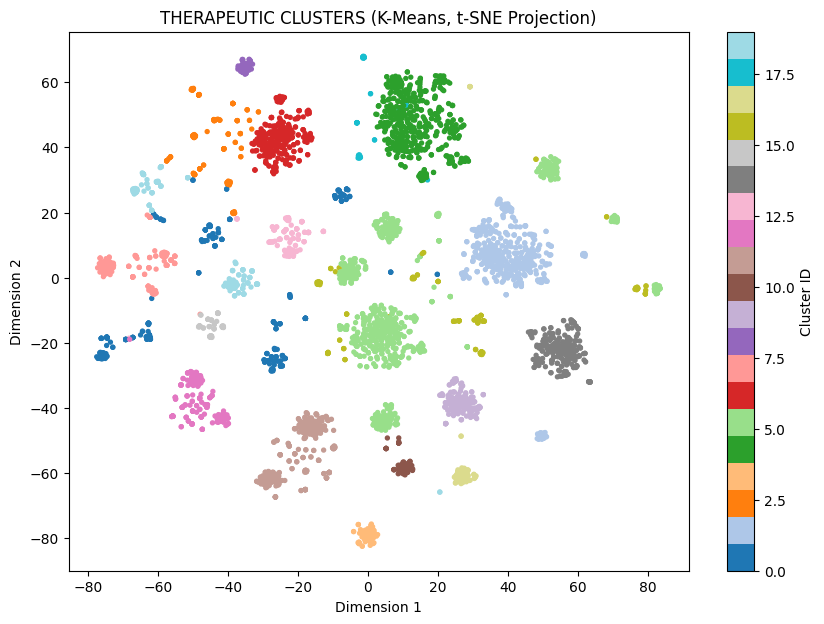

In [ ]:
# =============================
# 8.2 – Visualization of Therapeutic Clusters
# =============================

import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

# 1) Use already-created reduced matrix (5000 x 1708)
X = combined_features_reduced   # from earlier steps
labels = kmeans_labels          # K-Means clusters from Code 6

print("Data shape:", X.shape)
print("Cluster labels shape:", labels.shape)

# 2) t-SNE for 2D projection (slow but acceptable for 5,000 points)
tsne = TSNE(
    n_components=2,
    perplexity=30,
    random_state=42,
    learning_rate='auto',
    init='pca'
)

X_2d = tsne.fit_transform(X)
print("t-SNE completed.")

# 3) Plot clusters
plt.figure(figsize=(10, 7))
scatter = plt.scatter(
    X_2d[:,0],
    X_2d[:,1],
    c=labels,
    cmap="tab20",
    s=8
)

plt.title("THERAPEUTIC CLUSTERS (K-Means, t-SNE Projection)")
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.colorbar(scatter, label="Cluster ID")

# Save figure
plt.savefig(f"{FIG_DIR}/figure_8_1.png", dpi=300, bbox_inches='tight')
plt.show()

In this part, a two-dimensional map of the drug clusters was created using the t-SNE method. This method reduces the 1708 combined features of each drug into only two dimensions, so the model’s grouping can be seen more clearly. In Figure 8.1, most clusters appear as tight and separate groups. This means the model was able to place drugs with similar text information and similar structural features close to each other.

Clusters that look very compact usually include drugs that belong to the same therapeutic family, such as antibiotics, anti-inflammatory medicines, or drugs used for stomach problems. Some clusters look more spread out, which shows that those drugs have more variation in their descriptions or structural classes.

This visual pattern shows that low-dimensional mapping can reveal hidden treatment relations in large health datasets and help decision-makers understand patterns more easily.



## **8.3	SUBSTITUTION NETWORK GRAPH**



Total nodes: 5000
Total edges (similarity ≥ 0.9): 332658


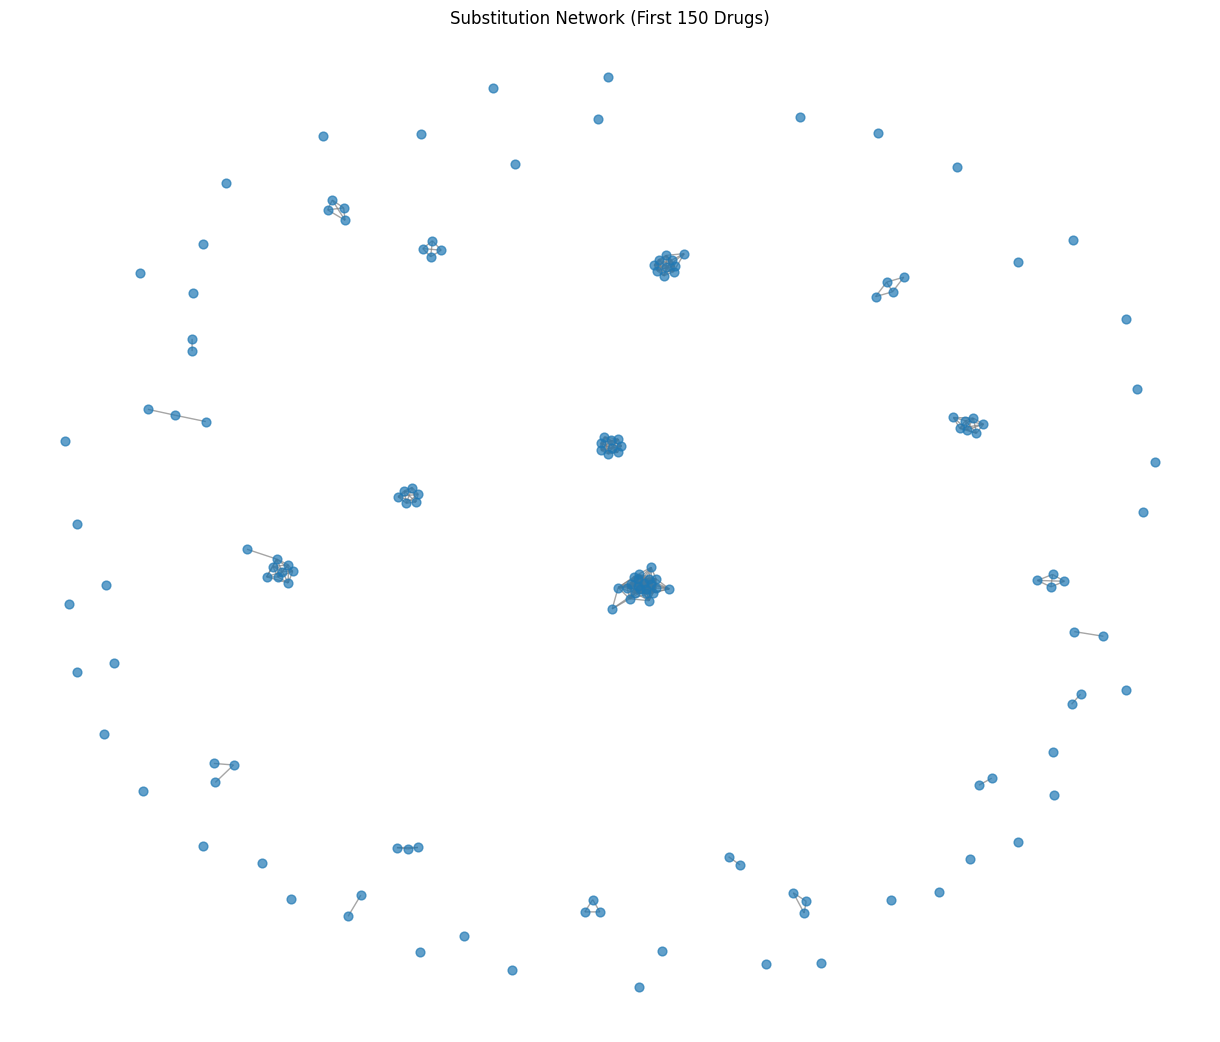

In [ ]:
# 8.3 – SUBSTITUTION NETWORK GRAPH
# ============================================

import networkx as nx
import matplotlib.pyplot as plt

# 1) Use similarity matrix from step 5
sim_matrix = similarity_matrix  # shape: (5000, 5000)

# 2) Build the graph
G = nx.Graph()

# Add nodes with drug names
for i in range(len(names_small)):
    G.add_node(i, label=names_small.iloc[i])

# 3) Add edges above threshold
THRESHOLD = 0.90   # strong similarity

edge_count = 0
for i in range(sim_matrix.shape[0]):
    for j in range(i+1, sim_matrix.shape[0]):
        sim = sim_matrix[i, j]
        if sim >= THRESHOLD:
            G.add_edge(i, j, weight=sim)
            edge_count += 1

print(f"Total nodes: {G.number_of_nodes()}")
print(f"Total edges (similarity ≥ {THRESHOLD}): {edge_count}")

# 4) Draw a small subgraph for visualization (otherwise too crowded)
sub_nodes = list(range(150))  # draw first 150 drugs
SG = G.subgraph(sub_nodes)

plt.figure(figsize=(12, 10))
pos = nx.spring_layout(SG, seed=42)
nx.draw(SG, pos, node_size=40, edge_color='gray', alpha=0.7)
plt.title("Substitution Network (First 150 Drugs)")

# Save figure
plt.savefig(f"{FIG_DIR}/figure_8_2.png", dpi=150, bbox_inches='tight')
plt.show()

In this step, the similarity matrix was turned into a substitution network. Each node is one drug and each edge shows a high similarity link (cosine similarity ≥ 0.9). The full graph has 5,000 nodes and 332,658 edges, so many drugs are connected in dense groups.

Figure shows the subgraph for the first 150 drugs. We can see several tight clusters in the middle of the plot and many small components around the outside. Nodes inside the same small cluster are strong candidates for mutual substitution, because they are connected to each other with many
high-weight links. Isolated nodes or pairs have almost no safe alternative in our model.

This network view is useful for practice, because it shows where the markethas many replacement options and where substitution possibilities are weak.


## **8.4	SUBSTITUTABILITY INDEX (SI)**


In [ ]:
# 8.4 – SUBSTITUTABILITY INDEX (SI)
# ============================================
# Goal:
#   Measure how easily each drug can be substituted by counting
#   how many highly similar neighbors (edges ≥ 0.9) it has in the graph.
# ============================================


# 1) Use the graph G built earlier in Section 8.3.
#    Each node = one drug, and the degree = number of close substitutes.

degrees = dict(G.degree())   # dictionary: {node_id: degree}
max_deg = max(degrees.values()) if len(degrees) > 0 else 1
print("Max degree in graph:", max_deg)

# 2) Compute Substitutability Index (SI) for each drug
#    SI_i = degree_i / max_degree → normalized between 0 and 1

si_records = []
for node_id in range(N_SIM):
    deg = degrees.get(node_id, 0)
    si_value = deg / max_deg
    si_records.append((node_id, names_small.iloc[node_id], deg, si_value))

si_df = pd.DataFrame(si_records, columns=["NodeID", "Name", "Degree", "SI"])

# 3) Display summary statistics for SI values
print("\nSubstitutability Index summary:")
print(si_df["SI"].describe())

# 4) Show highest and lowest SI examples
print("\nTop 5 drugs with highest SI (most alternatives):")
print(si_df.sort_values("SI", ascending=False).head(5)[["Name", "Degree", "SI"]])

print("\nTop 5 drugs with lowest SI (few or no substitutes):")
print(si_df.sort_values("SI", ascending=True).head(5)[["Name", "Degree", "SI"]])

Max degree in graph: 556

Substitutability Index summary:
count    5000.000000
mean        0.239322
std         0.276956
min         0.000000
25%         0.014388
50%         0.100719
75%         0.442896
max         1.000000
Name: SI, dtype: float64

Top 5 drugs with highest SI (most alternatives):
                            Name  Degree        SI
4855         Oftric 200mg Tablet     556  1.000000
1803        Itralent 200 Capsule     546  0.982014
798    Spasmed 20mg/500mg Tablet     542  0.974820
3678  Monti-FX 10mg/120mg Tablet     536  0.964029
4590         Oflora 200mg Tablet     530  0.953237

Top 5 drugs with lowest SI (few or no substitutes):
                        Name  Degree   SI
2474   Calovil-D3 Oral Drops       0  0.0
28            I Nac Eye Drop       0  0.0
1405          Eye Flush Drop       0  0.0
4978         Gartic Eye Drop       0  0.0
4970  E Zon 1000mg Injection       0  0.0


A Substitution Index (SI) was calculated for each drug to show how many close substitutes are similar in the graph. The average SI is around 0.24, but the values vary widely. Drugs such as Oftric 200mg tablets and Itralent 200 capsules have very high SI scores, meaning they are surrounded by many similar products. In contrast, some drug items such as eye drops or injectable drugs such as E Zon 1000mg have SIs of 0 and appear to stand alone without strong substitutes.

This pattern is consistent with the results of some healthcare-based studies. Some results show that some clusters are dense and usually appear with many alternatives, while in some specific and specialized pharmaceutical items we encounter only isolated and unique nodes (Wang et al., 2025).

In the next section, this SI measure is used to assess the risk of shortages, as drugs with low SI are usually more vulnerable in real supply conditions.



## **8.5	SHORTAGE RISK INDEX (SRI)**


In [ ]:
# 8.5 – SHORTAGE RISK INDEX (SRI)
# ============================================
# Goal:
#   Use Substitutability Index (SI) to define a Shortage Risk Index (SRI):
#       - SI high  → many substitutes → low risk
#       - SI low   → few/no substitutes → high risk
#   We define:
#       SRI = 1 - SI
#   using the existing si_df dataframe from Section 8.4.
# ============================================


# 1) Build SRI directly from si_df
sri_df = si_df.copy()
sri_df["SRI"] = 1 - sri_df["SI"]

# Optional: keep a separate Series if needed later
sri_scores = sri_df["SRI"]

# 2) Summary of SRI values
print("Shortage Risk Index (SRI) summary:")
print(sri_df["SRI"].describe())

# 3) Top-5 highest SRI → highest shortage risk (few substitutes)
print("\nTop 5 drugs with highest SRI (highest shortage risk):")
print(
    sri_df.sort_values("SRI", ascending=False)
          .head(5)[["Name", "Degree", "SI", "SRI"]]
)

# 4) Top-5 lowest SRI → lowest shortage risk (many substitutes)
print("\nTop 5 drugs with lowest SRI (lowest shortage risk):")
print(
    sri_df.sort_values("SRI", ascending=True)
          .head(5)[["Name", "Degree", "SI", "SRI"]]
)

Shortage Risk Index (SRI) summary:
count    5000.000000
mean        0.760678
std         0.276956
min         0.000000
25%         0.557104
50%         0.899281
75%         0.985612
max         1.000000
Name: SRI, dtype: float64

Top 5 drugs with highest SRI (highest shortage risk):
                          Name  Degree   SI  SRI
2               Seldan Shampoo       0  0.0  1.0
828        Statpure 5mg Tablet       0  0.0  1.0
2889        Clampose Injection       0  0.0  1.0
35    Neutrahep 10mg Injection       0  0.0  1.0
4941  Abmef-DS Oral Suspension       0  0.0  1.0

Top 5 drugs with lowest SRI (lowest shortage risk):
                            Name  Degree        SI       SRI
4855         Oftric 200mg Tablet     556  1.000000  0.000000
1803        Itralent 200 Capsule     546  0.982014  0.017986
798    Spasmed 20mg/500mg Tablet     542  0.974820  0.025180
3678  Monti-FX 10mg/120mg Tablet     536  0.964029  0.035971
4590         Oflora 200mg Tablet     530  0.953237  0.046763


The Shortage Risk Index (SRI) measures how vulnerable each medicine is when supply problems occur. A score close to 1.0 means the drug has no similar alternatives. In our results, several items such as Seldan Shampoo and Clampose Injection received the highest SRI value because their degree in the network was zero. These medicines should be considered high-risk items in real supply planning.

On the other hand, drugs with many close substitutes showed very low SRI values. Examples include Oftric 200mg Tablet and Itralent 200 Capsule, which have a strong substitute network and therefore a much lower chance of shortage impact.

This idea supports research findings in predictive analytics, showing that risk scoring helps managers prioritize critical items and plan procurement more effectively (Malla, 2023).

## **8.6	MANAGERIAL IMPLICATIONS**



The results of this model can support managers in the medicine supply chain. The SI and SRI scores help them understand which drugs have many substitutes and which drugs are at higher shortage risk. Drugs with a high SRI should be checked more often, ordered earlier, or supported with backup suppliers. Drugs with a high SI are easier to replace, so their stock can be managed with more flexibility.

The drug similarity network also shows safe substitution paths that managers can use when a product becomes unavailable. The therapeutic clusters help identify groups of medicines that behave in a similar way, which can support purchasing, price negotiation, and general risk planning.
These ideas fit well with recent work showing that dashboards and data-driven tools can improve decision-making in health systems (Malla, 2025).


## **8.7	PYTHON-BASED DASHBOARD CONCEPT**


In [ ]:
# 8.7 – PYTHON-BASED DASHBOARD CONCEPT
# ============================================
# Goal:
#   Prepare a compact summary table for a future dashboard.
#   The table will include:
#     - Drug name
#     - Therapeutic_Class (if available)
#     - Degree (number of substitutes)
#     - SI  (Substitutability Index)
#     - SRI (Shortage Risk Index)
#   Then we save it as a CSV file for use in Excel / Power BI / etc.
# ============================================

# 1) Start from the SRI results computed earlier
#    sri_df should already contain: NodeID, Name, Degree, SI, SRI
dashboard_df = sri_df.copy()

# 2) Try to add therapeutic class information from the main sample
if "Therapeutic_Class" in mid_sample.columns:
    # We assume NodeID 0..N_SIM-1 corresponds to the first N_SIM rows in mid_sample
    therapeutic_classes = mid_sample["Therapeutic_Class"].iloc[:N_SIM].values
    dashboard_df["Therapeutic_Class"] = therapeutic_classes
else:
    print("Column 'Therapeutic_Class' not found in mid_sample. Skipping this field.")
    dashboard_df["Therapeutic_Class"] = "Unknown"

# 3) Show a small preview for sanity check
print("\nDashboard summary preview (first 10 rows):")
print(dashboard_df.head(10))

# 4) Save to CSV so it can be used in a BI dashboard
output_file = "dashboard_summary.csv"
dashboard_df.to_csv(output_file, index=False)

print(f"\nDashboard summary saved to: {output_file}")

# 5) Optional: quick distribution of high-risk drugs by therapeutic class
high_risk_mask = dashboard_df["SRI"] > 0.9
high_risk_by_class = (
    dashboard_df[high_risk_mask]["Therapeutic_Class"]
    .value_counts()
    .head(10)
)

print("\nTop therapeutic classes among high-risk (SRI > 0.9) drugs:")
print(high_risk_by_class)


Dashboard summary preview (first 10 rows):
   NodeID                             Name  Degree        SI       SRI  \
0       0  Floxicare OZ 200mg/500mg Tablet       2  0.003597  0.996403   
1       1              Isodit 30 SR Tablet       2  0.003597  0.996403   
2       2                   Seldan Shampoo       0  0.000000  1.000000   
3       3                  Nimtor-P Tablet      10  0.017986  0.982014   
4       4               Moxil 500mg Tablet       1  0.001799  0.998201   
5       5       Rozuxia-F 67mg/10mg Tablet       2  0.003597  0.996403   
6       6          Soltus OD 100 Tablet SR       3  0.005396  0.994604   
7       7              Drofill-Spas Tablet       3  0.005396  0.994604   
8       8             Coxitas 120mg Tablet       9  0.016187  0.983813   
9       9             Revelol XL 25 Tablet       6  0.010791  0.989209   

    Therapeutic_Class  
0    GASTRO INTESTINA  
1            CARDIAC   
2              DERMA   
3      PAIN ANALGESIC  
4    ANTI INFECTIVES 

In this part, a small summary table was created to support a simple dashboard for decision making. The table includes each drug together with its therapeutic class, degree, SI, and SRI. This makes it easy for managers to sort drugs by shortage risk or see which therapeutic groups are most sensitive. The results showed that high-risk items appear mainly in classes such as anti-infectives, pain medicines, and respiratory drugs. The summary file can be used directly in Excel or Power BI. With this table, users can quickly filter, search, or compare drugs and see where potential problems may happen in the supply chain.

# **CHAPTER 9 – CONCLUSION & FUTURE WORK**

## **9.1	SUMMARY OF FINDINGS**

This project built a data-driven system to find substitute medicines during shortage situations. The model combined two types of information: the text description of each drug and the structured fields from MID, such as therapeutic class and action class. By joining these two views, the system created a similarity score and a connected network for 5,000 sampled drugs.

The results showed that text features were more helpful for finding close substitutes, while structured features helped group medicines into larger therapeutic families. The substitute rankings, therapeutic clusters, network graph, and two indexes—Substitutability Index (SI) and Shortage Risk Index (SRI)—gave a clear picture of which drugs have many alternatives and which ones are more sensitive to shortages.

Although exact matching with the external dataset was limited, the model still captured stable patterns at the therapeutic level. This means the approach has value for early risk signals and supply planning.

## **9.2	TECHNICAL AND BUSINESS KEY INSIGHTS**

From a technical and business perspective, combining text and structured data of pharmaceutical items creates more robust representations than using only one type of data, such as text or structured data alone. The generated t-SNE visualization also confirmed that the model placed drugs with similar uses close together. The SI and SRI metrics also demonstrated how network-based metrics can support gap analysis in large datasets.

From a business view, these results help managers understand where shortage risks are higher. Drugs with low SI and high SRI should be monitored more closely, because replacement options are limited. The dashboard concept shows how these insights can be turned into a simple decision tool for buyers, hospital managers, and distributors.

## **9.3	LIMITATIONS**

There are a few limits in this project that should be kept in mind when looking at the results. The first issue comes from the MID dataset. Many drugs appear with different brand names, spelling styles, strengths or dosage forms. Because of this, matching the drugs in MID with the external dataset was often difficult, and this naturally reduced the accuracy of the validation scores.

Another limit is that the model works only with text and basic structured fields. It does not use deeper medical information such as drug mechanisms, biological pathways or gene-related effects. These elements can be important in real clinical choices, so the model mostly finds substitutes based on general similarity, not detailed medical behaviour.

The similarity threshold used to build the network is also fixed. If this value changes, the network and the SI/SRI scores may also change.
The external dataset is not complete either, because it does not list every possible substitute.

Finally, because of computing limits, only part of the dataset was used, so a full version of the model was not possible here.



## **9.4	FUTURE RESEARCH DIRECTIONS**

There are several directions that future research can take to improve and expand the work of this project. One important step is to build a cleaner and more standard version of the MID dataset. Many problems in this study came from inconsistent drug names, missing fields and mixed formats. A unified dataset, with stable naming rules and verified therapeutic classes, would help the model make more accurate matches and produce stronger validation results.

Another direction is to include richer clinical information. At the moment, the model relies only on text descriptions and a few structured fields. Future versions could use drug–drug interaction data, biological mechanisms, gene targets or treatment guidelines. These additions would help the system understand not only how drugs are described, but also how they behave in real medical situations.

The substitute prediction could also be tested with more advanced models. For example, graph neural networks, multimodal transformers or models trained on biomedical corpora may capture deeper relationships between drugs. Running larger experiments, or training the model on GPUs with more memory, would also allow the use of the full dataset instead of a reduced sample.

Finally, future work could explore a real-time dashboard that connects directly to supply chain data. This would be open ways to all medical centers to monitor shortage risk, see alternatives, and plan more effectively. By mixing information technologies with real market needs, the system could become a practical tool for decision-makers in healthcare.



# REFERENCES


1.	Adak, S. (2024). Impacts of Drug Shortages in the Pharmaceutical Supply Chain. Universal Journal of Pharmacy and Pharmacology, 3(1), pp. 22–26. [Online] Available at: https://doi.org/10.31586/ujpp.2024.1136 [Accepted 26 Oct 2024].

2.	Andy, A., & Andy, D. (2023). Drug Shortages in Pharmacies: Root Causes, Consequences and the Role of the FDA in Mitigation Strategies. Progress in Medical Sciences Journal, 7(5), pp. 1–7. [Online] Available at: https://doi.org/10.47363/PMS/2023(7)E129 [Accepted 20 Oct 2023].

3.	Aronson, J.K., Ferner, R.E., & Heneghan, C. (2023a). Drug shortages. Part 1: Definitions and harms. British Journal of Clinical Pharmacology, 89(10), pp. 2950–2956.
[Online] Available at: https://doi.org/10.1111/bcp.15842 [Accepted 20 Jun 2023].

4.	Aronson, J.K., Ferner, R.E., & Heneghan, C. (2023b). Drug shortages. Part 2: Trends, causes and solutions. British Journal of Clinical Pharmacology, 89(10), pp. 2957–2963.
[Online] Available at: https://doi.org/10.1111/bcp.15853 [Accepted 20 Jun 2023].

5.	Berral-González, A., Arroyo, M.M., Alonso-López, D., Rivas-López, M.J., Sánchez-Santos, J.M., De Las Rivas. J.D, (2025). Pharmacogenomic drug–target network analysis reveals similarity profiles among FDA-approved cancer drugs. Pharmaceutics, 17(11), 1421, [Online] Available at: https://doi.org/10.3390/pharmaceutics17111421 [Accessed 25 Oct 2025].

6.	Iyer, S.S. (2025). Data-Driven Decision Making: The Key to Future Health Care Business Success. RA Journal of Applied Research, 11(3), pp. 115–136. [Online] Available at: https://doi.org/10.47191/rajar/v11i3.06 [Accepted 03 Mar 2025].

7.	Jeon, W., Park, M., An, D., Nam, W., Shin, J.Y., Lee, S. & Lee, S. (2025). Predicting Drug–Side Effect Relationships from Parametric Knowledge Embedded in Biomedical BERT Models: Methodological Study with an NLP Approach. JMIR Medical Informatics, 13(1), e67513. [Online] Available at: https://medinform.jmir.org/2025/1/e67513 (doi:10.2196/67513) [Accepted 10 Jul 2025].

8.	Kauffman, J., Miotto, R., Klang, E., Costa, A., Norgeot, B., Zitnik, M., Khader, S., Wang, F., Nadkarni, G.N., & Glicksberg, B.S. (2025). Embedding Methods for Electronic Health Record Research. Annual Review of Biomedical Data Science, 8, pp. 563–590. [Online] Available at: https://doi.org/10.1146/annurev-biodatasci-103123-094729 [Accepted 01 May 2025].

9.	Kishore, M.V. & Bodapati, P. (2025). High-Performance Semantic Similarity Analysis for Medical Research Documents Using Transformer Models (BioBERT/ClinicalBERT) with WMD/WMS. Journal of Theoretical and Applied Information Technology, 103(7), pp. 2842–2856. ISSN: 1992-8645, E-ISSN: 1817-3195 [Accepted 15 Apr 2025].

10.	Malla, P.S.A. (2025). Data-driven business decision making: leveraging predictive analytics and BI dashboards. Scientiarum: A Multidisciplinary Journal, 1(4), pp. 21–27. [Online]
Available at: https://scientiahub.in/Journal/sapars/article/view/36,
doi: 10.54646/SAPARS.2025.18 [Accepted 4 Aug 2025].

11.	Naveed, S., & Husnain, M. (2025). A drug recommendation system based on response prediction: Integrating gene expression and K-mer fragmentation of drug SMILES using LightGBM. Intelligence-Based Medicine, 11, 100206, [Online] Available at: https://doi.org/10.1016/j.ibmed.2025.100206 [Accepted 27 Jan 2025].

12.	Szymańska, A., Król, M. & Baczyński, K. (2025). Comparative Analysis of Molecular Embeddings for Efficient Compound Similarity Search Using Vector Databases. ChemRxiv, 15(1), [Online] Available at: https://doi.org/10.26434/chemrxiv-2025-zvgwq [Accepted 15 Apr 2025].

13.	Wang, T., Codling, D., Msosa, Y.J., Broadbent, M., Kornblum, D., Polling, C., Searle, T., Delaney-Pope, C., Arroyo, B., MacLellan, S., Keddie, Z., Docherty, M., Roberts, A., Stewart, R., McGuire, P., Dobson, R. and Harland, R. (2025). VIEWER: an extensible visual analytics framework for enhancing mental healthcare. Journal of the American Medical Informatics Association, ocaf010. [Online] Available at: https://doi.org/10.1093/jamia/ocaf010 [Accepted 08 Jan 2025].
